In [1]:
REPO = "shuyizhang01/Time-consistent_Deephedging"

!git clone https://github.com/{REPO}.git /kaggle/working/DeepHedging
!apt-get install tree -y
!tree -L 4 /kaggle/working/DeepHedging

Cloning into '/kaggle/working/DeepHedging'...
remote: Enumerating objects: 308, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 308 (delta 28), reused 67 (delta 24), pack-reused 231 (from 2)
Receiving objects: 100% (308/308), 18.87 MiB | 18.61 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Filtering content: 100% (75/75), 664.31 MiB | 18.25 MiB/s, done.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (52.3 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unp

In [2]:
"""
Loads the trained hedging environment + all saved actor/critic checkpoints
for plotting/evaluation.
"""
import re
import sys
from pathlib import Path

import numpy as np
import torch
import yaml

repo_path = "/kaggle/working/DeepHedging"
sys.path.insert(0, repo_path)
%cd /kaggle/working/DeepHedging
from src.basket_pricing.basket import BasketOptionValuationSystem
from src.envs.DCCGARCH import DCCGARCHSimulator
from src.envs.HedgingEnv import HedgingEnv
from src.agents.DynamicRiskModel import Actor, Critic_VaR_Excess
from src.agents.StaticRiskModel import MLPActorStatic

CONFIG_PATH = Path(repo_path) / "cfgs" / "configDynamicRisk.yaml"


def _extract_state_dict(obj, key_candidates=("actor", "model", "state_dict")):
    if isinstance(obj, dict):
        if obj and all(torch.is_tensor(v) for v in obj.values()):
            return obj
        for key in key_candidates:
            inner = obj.get(key)
            if isinstance(inner, dict) and inner and all(torch.is_tensor(v) for v in inner.values()):
                return inner
    raise ValueError(f"Could not locate a state_dict; top-level keys were "
                      f"{list(obj.keys()) if isinstance(obj, dict) else type(obj)}")


if __name__ == "__main__":
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)

    market_cfg = cfg["market"]
    dcc_cfg    = cfg["dcc"]
    env_cfg    = cfg["env"]
    actor_cfg  = cfg["actor"]
    critic_cfg = cfg["critic"]
    tr_cfg     = cfg["training"]

    garch_params_cfg = cfg["garch_params"]
    garch_params = {int(k): v for k, v in garch_params_cfg.items()}

    nu_Q      = dcc_cfg["nu_Q"]
    dcc_alpha = dcc_cfg["dcc_alpha"]
    dcc_beta  = dcc_cfg["dcc_beta"]
    Q_bar     = np.asarray(dcc_cfg["Q_bar"], dtype=float)
    r_daily   = market_cfg["r_daily"]

    print(f"Calibration loaded from config: nu_Q={nu_Q:.4f}, "
          f"dcc_alpha={dcc_alpha:.6f}, dcc_beta={dcc_beta:.6f}")
    print(f"Q_bar:\n{Q_bar}")

    print("Loading basket option system...")
    system = BasketOptionValuationSystem.load(
        str(Path(repo_path) / cfg["pricing"]["system_path"])
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"

    print("Creating DCC-GARCH simulator...")
    simulator = DCCGARCHSimulator(
        params=garch_params,
        Q_bar=Q_bar,
        dcc_alpha=dcc_alpha,
        dcc_beta=dcc_beta,
        nu_Q=nu_Q,
        r_daily=r_daily,
        device=device,
    )

    print("Creating hedging environment...")
    env = HedgingEnv(
        simulator=simulator,
        system=system,
        K=env_cfg["K"],
        T_days=env_cfg["T_days"],
        S0=env_cfg["S0"],
        r=env_cfg["r"],
        transaction_cost=env_cfg["transaction_cost"],
    )
    n_groups         = tr_cfg["n_groups"]
    group_size       = env.T_days // n_groups
    actor_hidden_dim = actor_cfg["hidden_dim"]
    actor_fixed_std  = actor_cfg["fixed_std"]
    head_dim_var     = critic_cfg["head_dim_var"]
    head_dim_excess  = critic_cfg["head_dim_excess"]

    dynamic_risk_path = Path(repo_path) / "dynamicriskmodels"
    model_folders = [f for f in dynamic_risk_path.rglob('*') if (f / 'actor.pt').exists()]

    all_models = {}
    all_norms  = {}

    for folder in sorted(model_folders):
        parts = folder.parts
        alpha = next((p for p in parts if p.startswith('alpha')), None)
        if alpha is None:
            continue
        scoring = folder.name
        if scoring == alpha:
            continue

        try:
            actor_ckpt = torch.load(folder / "actor.pt", map_location="cpu", weights_only=False)
            actor_sd = _extract_state_dict(actor_ckpt) if isinstance(actor_ckpt, dict) and not all(
                torch.is_tensor(v) for v in actor_ckpt.values()
            ) else actor_ckpt

            actor_loaded = Actor(
                state_dim=env.state_dim,
                action_dim=env.action_dim,
                hidden_dim=actor_hidden_dim,
                fixed_std=actor_fixed_std,
            )
            actor_loaded.load_state_dict(actor_sd)
            actor_loaded.eval()
        except Exception as e:
            print(f"  Failed to load actor.pt for {alpha}/{scoring}: {e}")
            continue

        critics_path = folder / "critics.pt"
        critics_state_dicts = None
        wo = False
        for wo in [False, True]:
            try:
                critics_state_dicts = torch.load(critics_path, map_location='cpu', weights_only=wo)
                break
            except Exception:
                continue
        if critics_state_dicts is None:
            print(f" Skipping {alpha}/{scoring} — critics.pt unreadable")
            continue

        critics = []
        try:
            for i in range(n_groups):
                c = Critic_VaR_Excess(
                    env.state_dim, group_size,
                    head_dim_var=head_dim_var, head_dim_excess=head_dim_excess
                )
                sd = critics_state_dicts[str(i)] if isinstance(critics_state_dicts, dict) and str(i) in critics_state_dicts \
                    else critics_state_dicts[i]
                c.load_state_dict(sd)
                c.eval()
                critics.append(c)
        except Exception as e:
            print(f" Failed to instantiate critics for {alpha}/{scoring}: {e}")
            continue

        try:
            ckpt_path = folder / f"{scoring}{alpha}.pt"
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=wo)
        except Exception as e:
            print(f" Failed to load checkpoint for {alpha}/{scoring}: {e}")
            continue

        if "b_list" not in ckpt:
            print(f" Skipping {alpha}/{scoring} — checkpoint missing 'b_list'")
            continue

        if alpha not in all_models:
            all_models[alpha] = {}
            all_norms[alpha]  = {}

        all_models[alpha][scoring] = {"actor": actor_loaded, "critics": critics}
        all_norms[alpha][scoring]  = {"b_values": ckpt['b_list']}
        print(f"  ✓ {alpha} / {scoring} loaded")
    static_risk_path = Path(repo_path) / "staticriskmodels"

    alpha_str_map = {
        "0.925": "alpha925",
        "0.95":  "alpha95",
        "0.975": "alpha975",
        "0.99":  "alpha99",
    }

    all_static_models = {}

    for pth_file in sorted(static_risk_path.glob("static_actor_alpha*.pth")):
        stem = pth_file.stem
        match = re.search(r"alpha([0-9]*\.?[0-9]+)", stem)
        if not match:
            continue
        alpha_key = alpha_str_map.get(match.group(1))
        if alpha_key is None:
            continue

        try:
            static_ckpt = torch.load(pth_file, map_location="cpu", weights_only=False)
            static_sd = _extract_state_dict(static_ckpt) if isinstance(static_ckpt, dict) and not all(
                torch.is_tensor(v) for v in static_ckpt.values()
            ) else static_ckpt
            static_actor = MLPActorStatic(
                state_dim=env.state_dim,
                action_dim=env.action_dim,
                hidden_dim=actor_hidden_dim,
                action_high=actor_cfg["action_high"],
            )
            static_actor.load_state_dict(static_sd)
            static_actor.eval()
            all_static_models[alpha_key] = {"actor": static_actor}
            print(f" {alpha_key} static actor loaded")
        except Exception as e:
            print(f" Failed to load {pth_file.name}: {e}")

    print("\n=== Loaded Dynamic Models ===")
    for alpha, funcs in all_models.items():
        for func in funcs:
            print(f"  {alpha} -> {func} -> actor + {len(funcs[func]['critics'])} critics")

    print("\n=== Loaded Static Models ===")
    for alpha in all_static_models:
        print(f"  {alpha} -> static actor")

/kaggle/working/DeepHedging
Calibration loaded from config: nu_Q=15.9241, dcc_alpha=0.016450, dcc_beta=0.965177
Q_bar:
[[1.         0.82815965 0.71671135 0.77464431]
 [0.82815965 1.         0.77532536 0.82266498]
 [0.71671135 0.77532536 1.         0.71968242]
 [0.77464431 0.82266498 0.71968242 1.        ]]
Loading basket option system...
✓ System loaded from /kaggle/working/DeepHedging/src/basket_pricing/artifacts/basket_system_dcc_surrogate.pkl
  - 4 assets, input dim: 16, weight type: dollar
Creating DCC-GARCH simulator...
Creating hedging environment...
  ✓ alpha925 / arcsin loaded
  ✓ alpha925 / arcsinh loaded
  ✓ alpha925 / arctan loaded
  ✓ alpha925 / log loaded
  ✓ alpha925 / power03 loaded
  ✓ alpha925 / rational loaded
  ✓ alpha95 / arcsin loaded
  ✓ alpha95 / arcsinh loaded
  ✓ alpha95 / arctan loaded
  ✓ alpha95 / log loaded
  ✓ alpha95 / power03 loaded
  ✓ alpha95 / rational loaded
  ✓ alpha975 / arcsin loaded
  ✓ alpha975 / arcsinh loaded
  ✓ alpha975 / arctan loaded
  ✓ a

In [ ]:
import os
import sys
import runpy
from src.visualization.plot import (
    plot_g2_functions,
    plot_portfolio_delta,
    plot_pnl_distributions,
    compute_terminal_stats,
    plot_scoring_curvature,
    plot_extreme_trajectory,
    plot_static_risk_across_maturities,
    plot_training_curves_by_scoring,
    ALPHA_LABELS,
    SCORING_KEYS,
)
from src.risk_measures.loss_functions import SCORE_FUNCTIONS
from src.envs.HedgingEnv import HedgingEnv
from src.agents.DynamicRiskModel import Actor
from src.agents.StaticRiskModel import MLPActorStatic

repo_path = "/kaggle/working/DeepHedging"
os.chdir(repo_path)
sys.path.insert(0, repo_path)

_ = runpy.run_path(
    "scripts/generate_data.py",
    init_globals={
        "env": env,
        "all_models": all_models,
        "all_static_models": all_static_models,
        "DATA_DIR": "/kaggle/working/data"
    },
    run_name="__main__",
)


  Generating FIXED paths (S0=100 all assets, h0=unconditional var)
  seed=42  batch=10000
    fixed paths saved to /kaggle/working/data/alpha925/_shared_paths
  fixed rollout alpha925 / arcsin ...
    saved to /kaggle/working/data/alpha925/_shared_paths/arcsin
    terminal P&L: mean=-0.9335  CVaR95=3.6982
  fixed rollout alpha925 / arcsinh ...
    saved to /kaggle/working/data/alpha925/_shared_paths/arcsinh
    terminal P&L: mean=-1.0690  CVaR95=3.8853
  fixed rollout alpha925 / arctan ...
    saved to /kaggle/working/data/alpha925/_shared_paths/arctan
    terminal P&L: mean=-0.9480  CVaR95=3.7236
  fixed rollout alpha925 / log ...
    saved to /kaggle/working/data/alpha925/_shared_paths/log
    terminal P&L: mean=-1.0652  CVaR95=3.8929
  fixed rollout alpha925 / power03 ...
    saved to /kaggle/working/data/alpha925/_shared_paths/power03
    terminal P&L: mean=-1.1447  CVaR95=3.9297
  fixed rollout alpha925 / rational ...
    saved to /kaggle/working/data/alpha925/_shared_paths/ratio

Saved -> /kaggle/working/figures/g2_functions.pdf
Saved -> /kaggle/working/figures/g2_functions.png


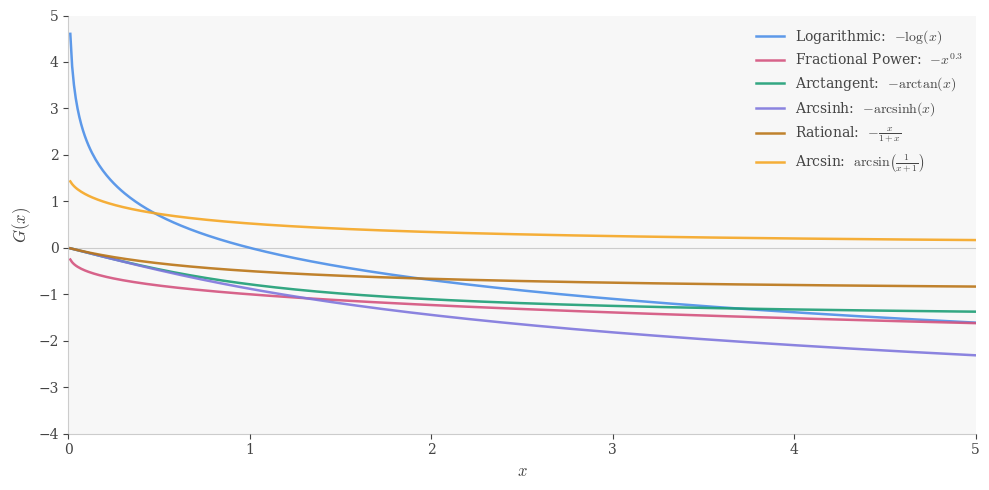

Saved -> /kaggle/working/figures/scoring_curvature_full.pdf
Saved -> /kaggle/working/figures/scoring_curvature_full.png


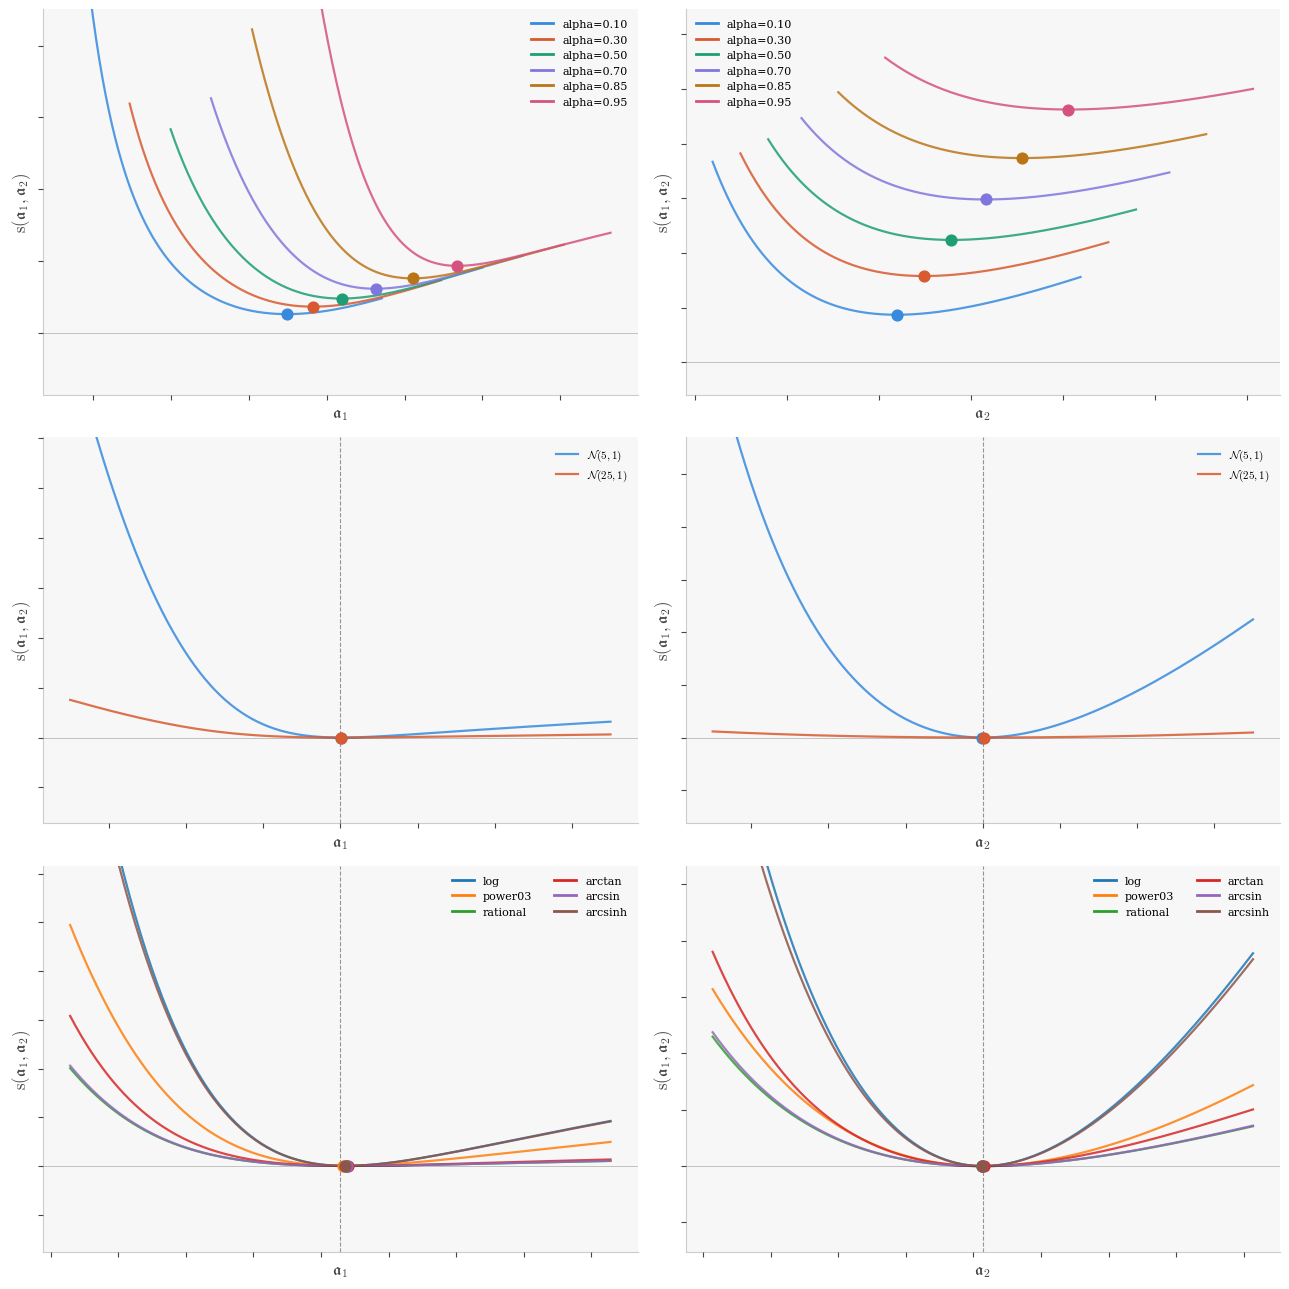

Saved -> /kaggle/working/figures/terminal_stats.csv

=== alpha925 (alpha=0.925) ===
Saved -> /kaggle/working/figures/pnl_distributions.pdf
Saved -> /kaggle/working/figures/pnl_distributions.png


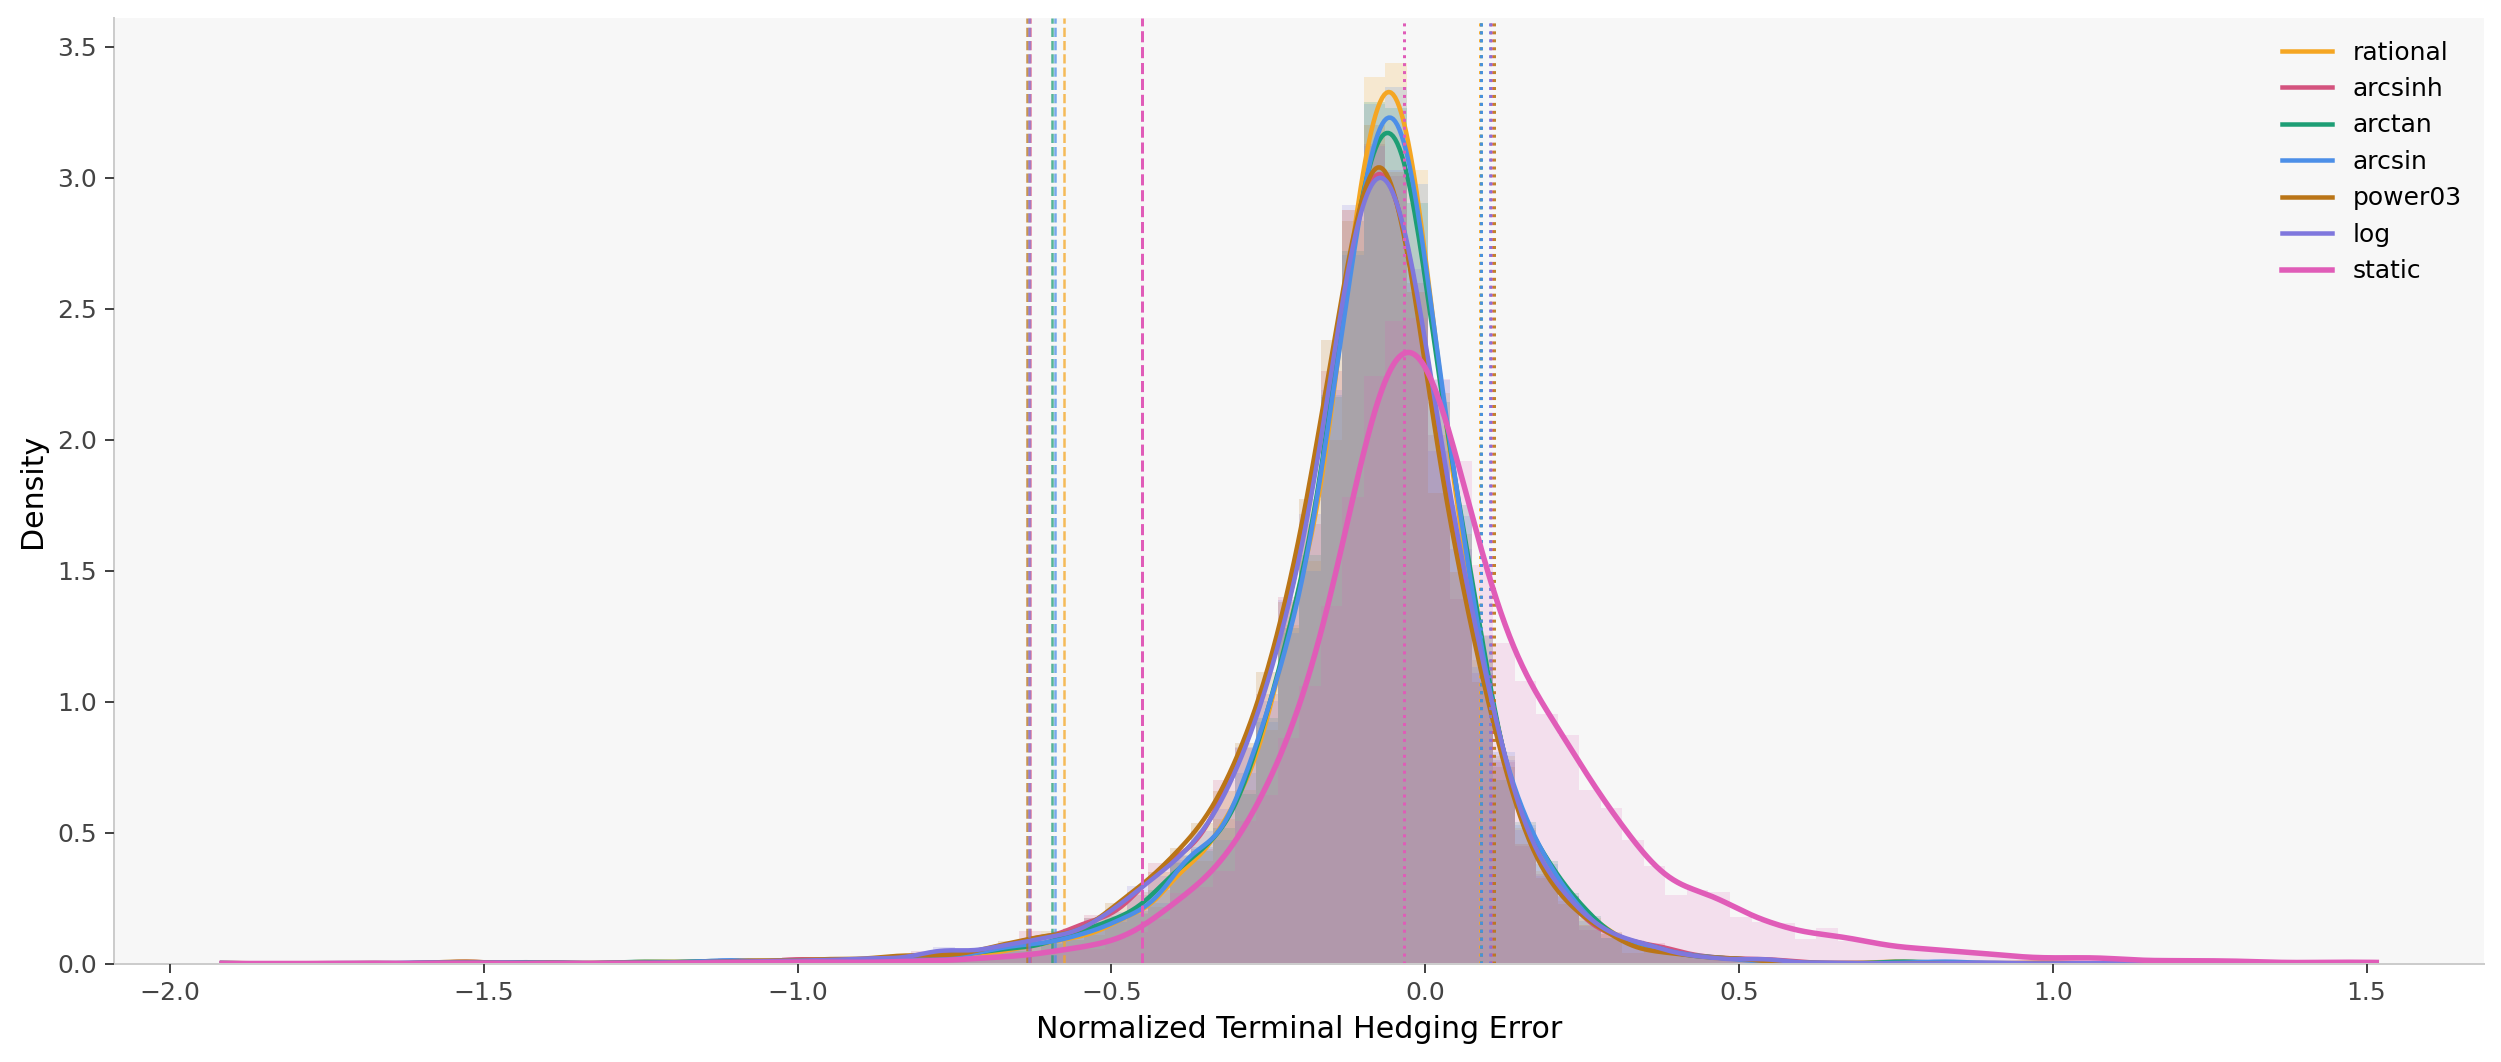

Hard trajectory (max realized gamma P&L, last 20d): idx=294  score=0.924170  (basket start=110.10  end=104.70, moneyness_end=1.047)
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.pdf
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.png


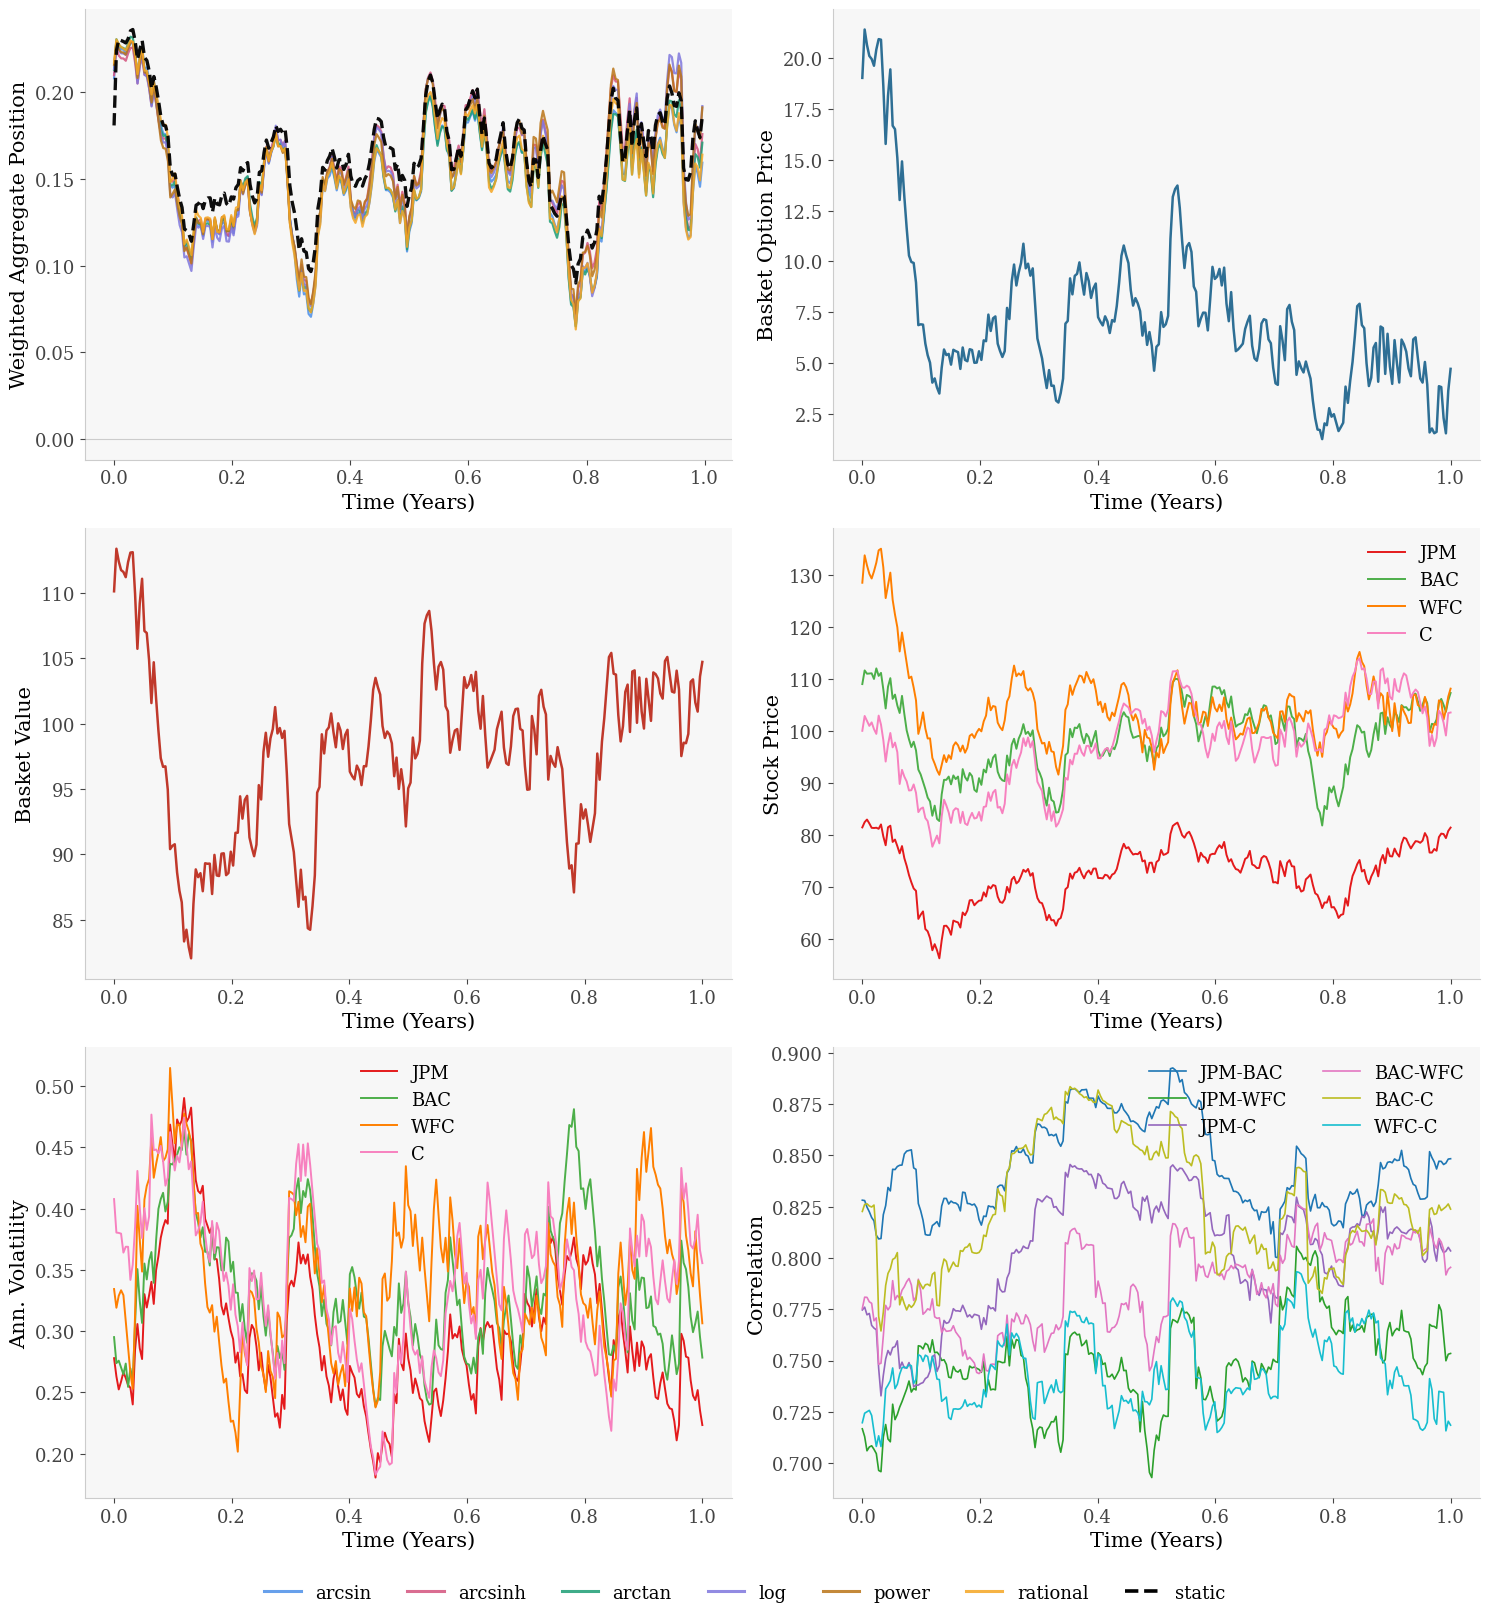


=== alpha95 (alpha=0.95) ===
Saved -> /kaggle/working/figures/portfolio_delta_plot.pdf
Saved -> /kaggle/working/figures/portfolio_delta_plot.png


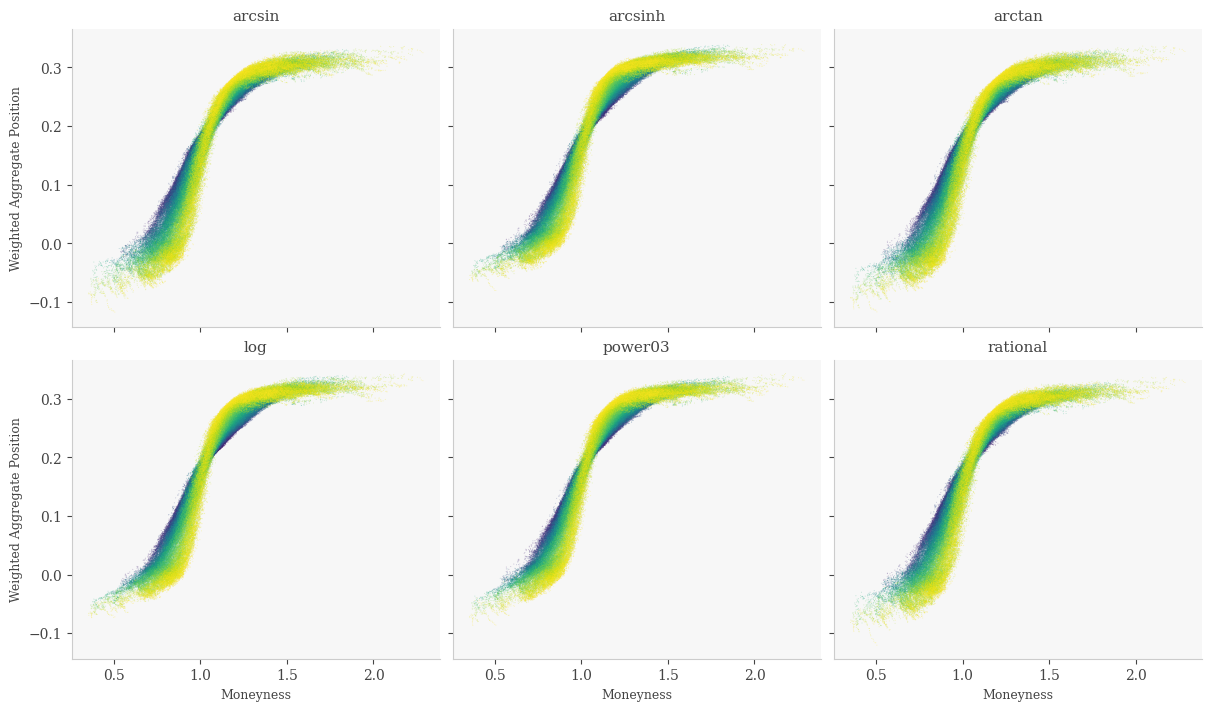

Saved -> /kaggle/working/figures/pnl_distributions.pdf
Saved -> /kaggle/working/figures/pnl_distributions.png


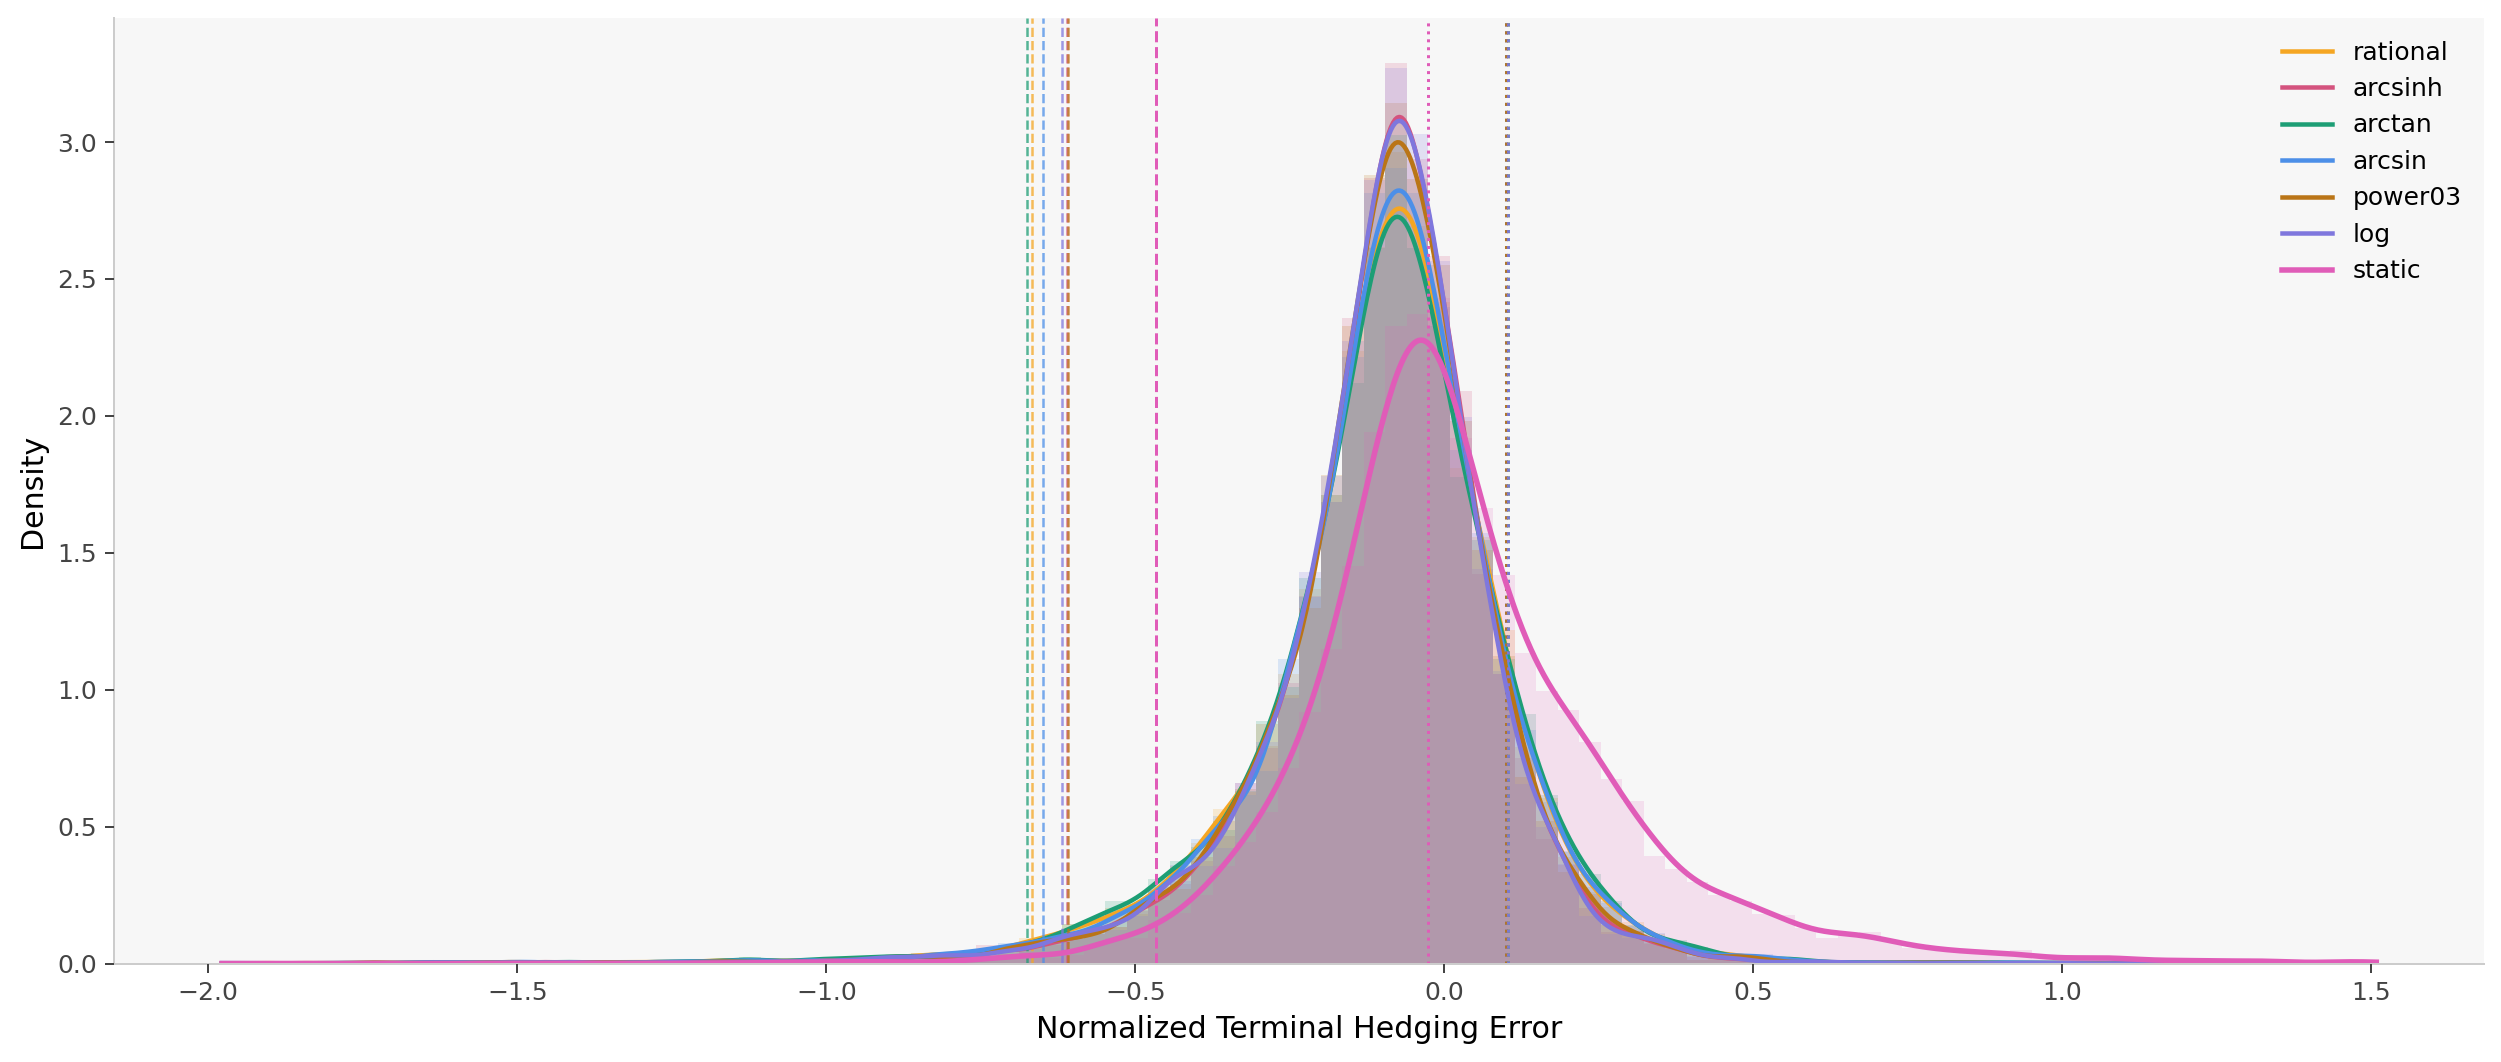

Hard trajectory (max realized gamma P&L, last 20d): idx=294  score=0.924170  (basket start=110.10  end=104.70, moneyness_end=1.047)
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.pdf
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.png


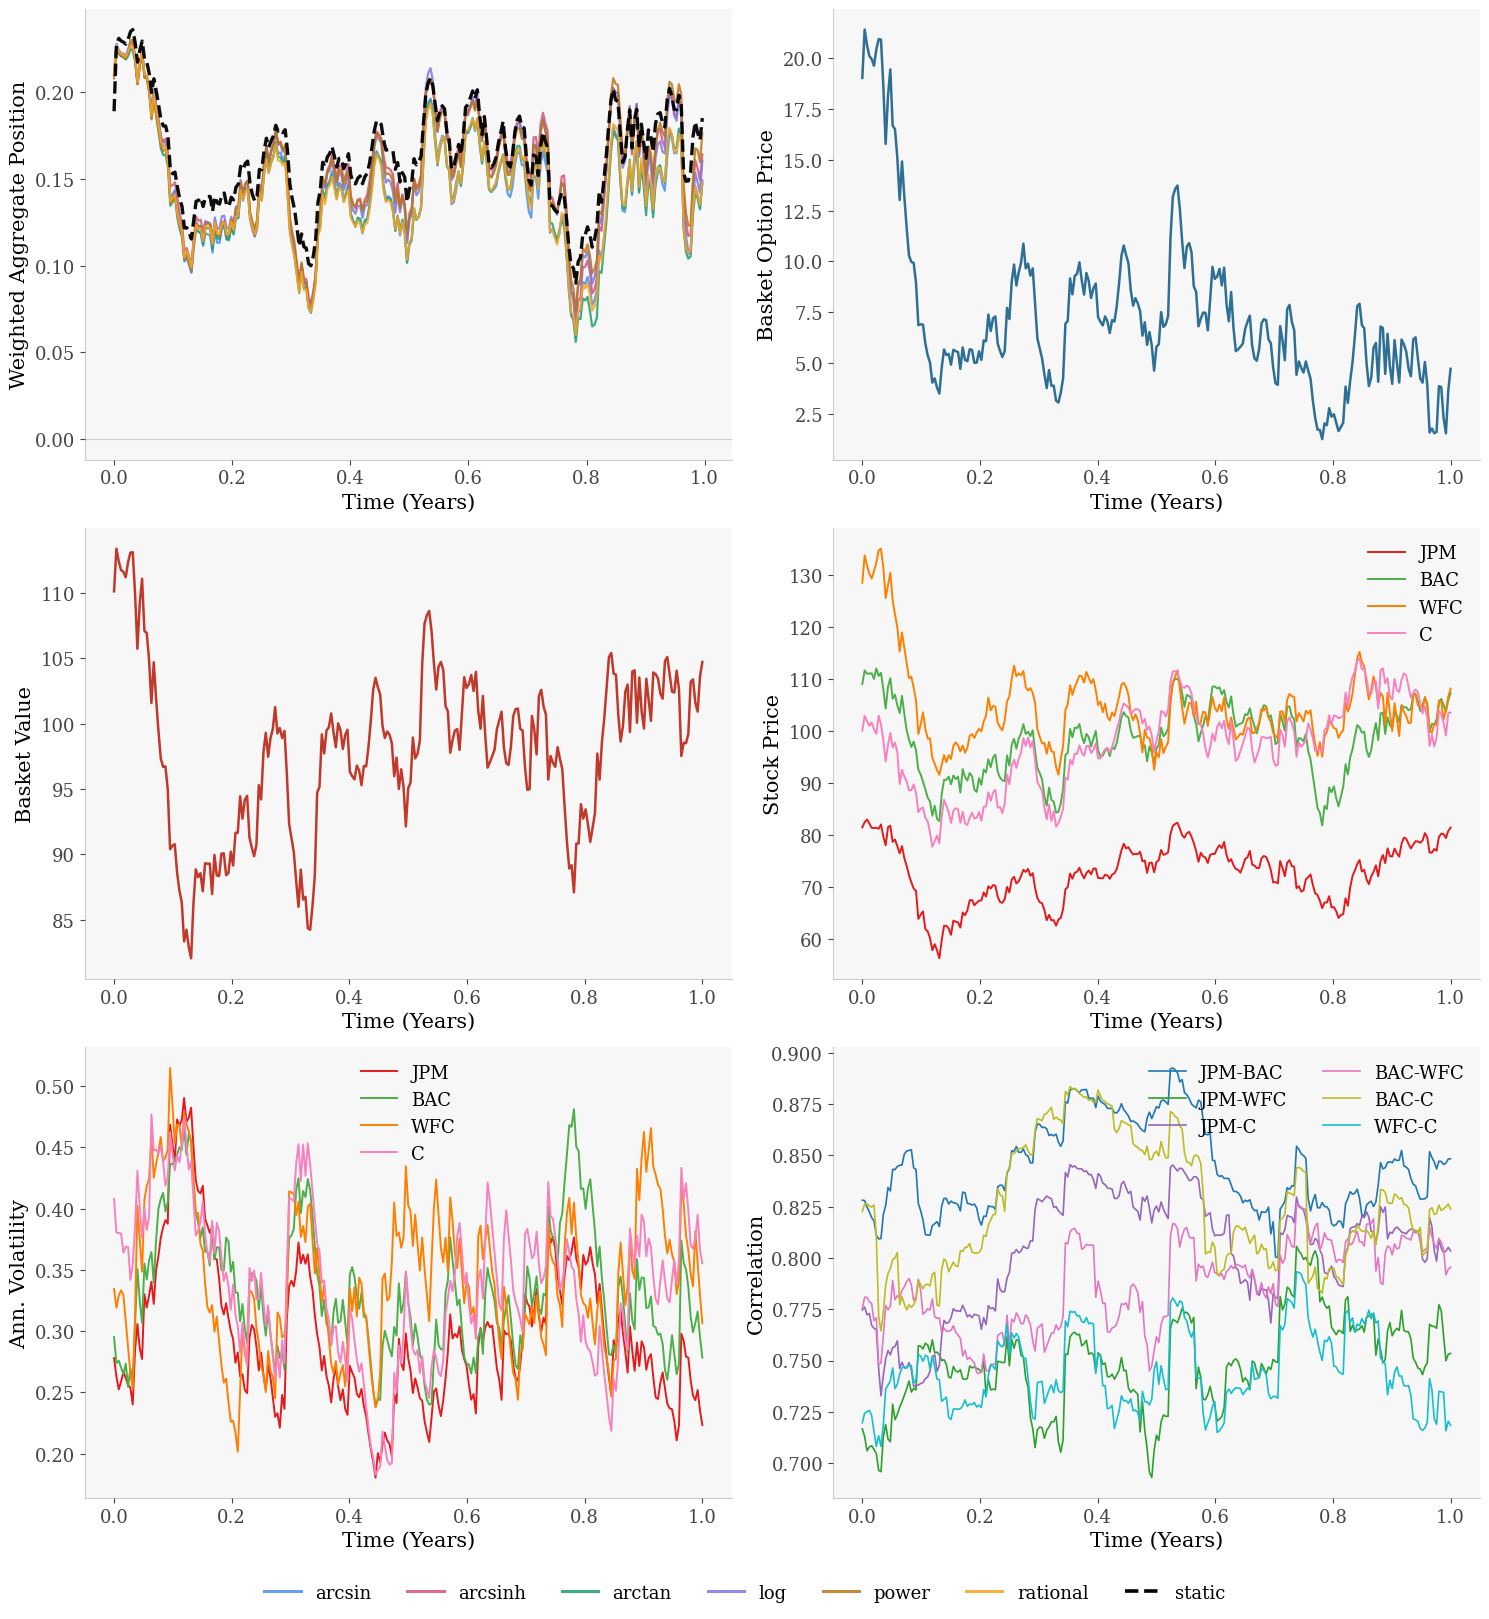

Saved -> /kaggle/working/figures/losses_cvar_alpha95.pdf
Saved -> /kaggle/working/figures/losses_cvar_alpha95.png


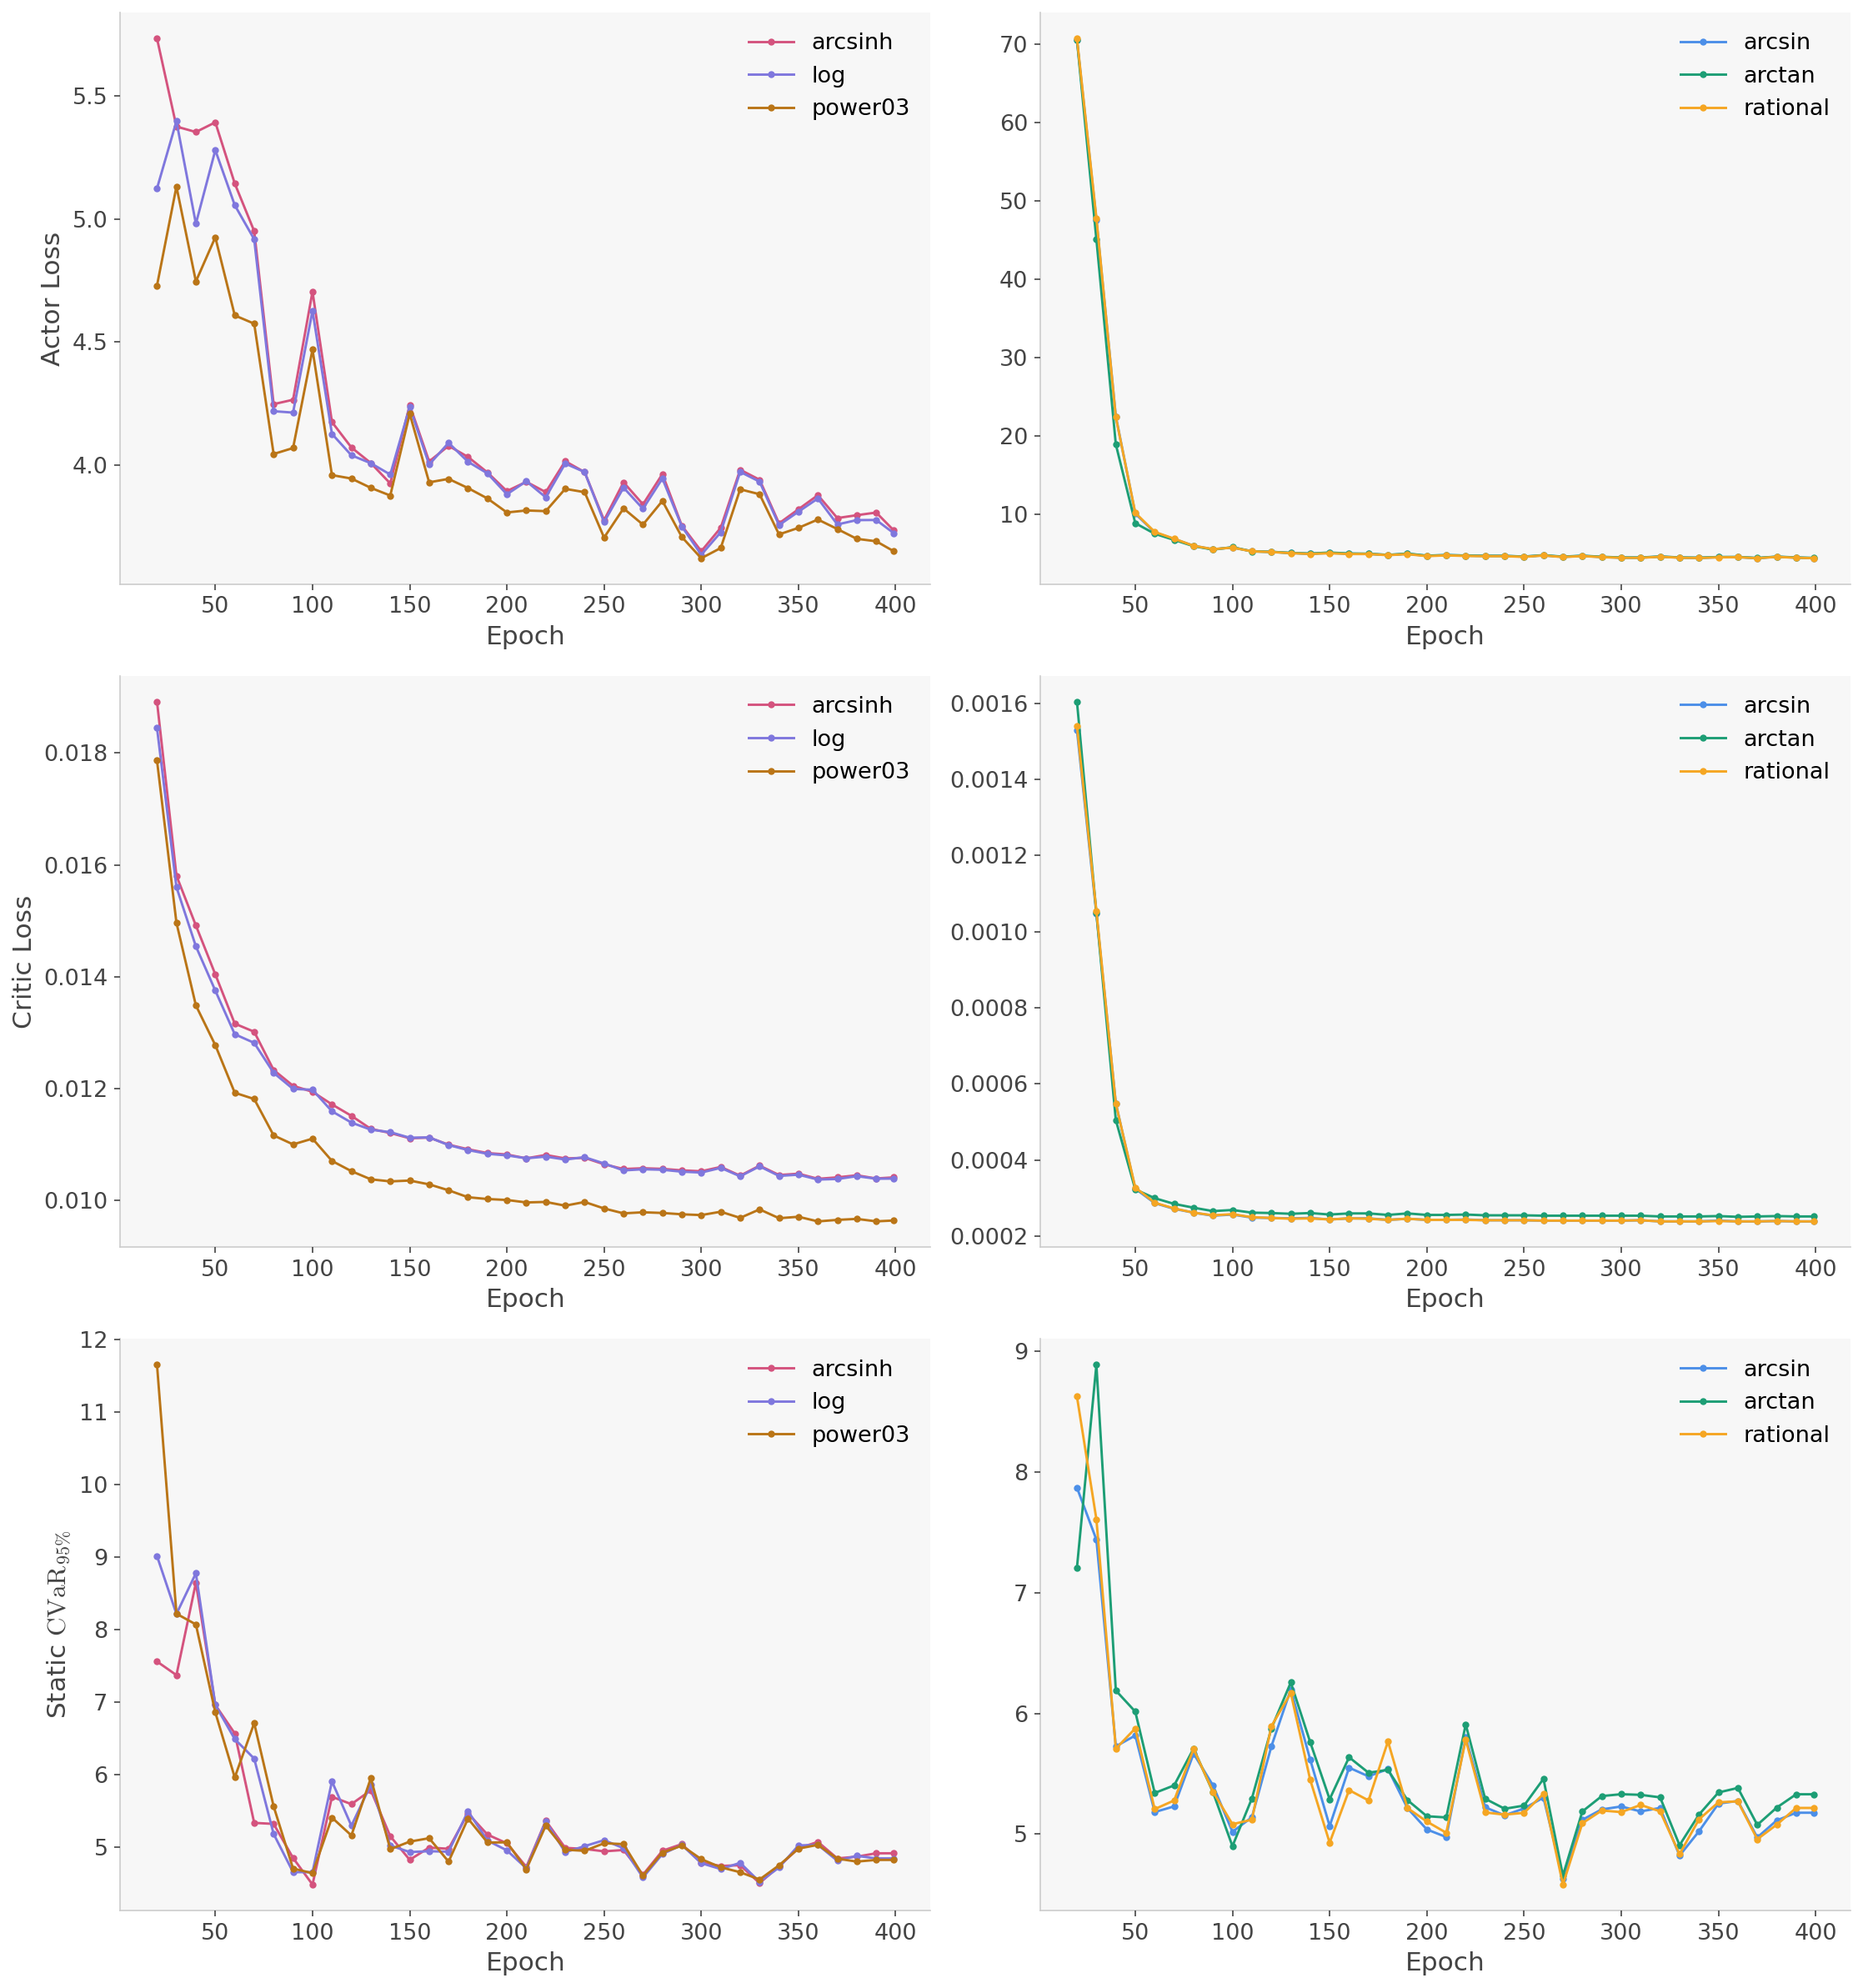

Evaluating alpha=0.95
  [SRM] T=252: mean_loss=-0.2161  CVaR_95=4.1595  CVaR_95=4.1595
  [SRM] T=251: mean_loss=-0.2159  CVaR_95=4.1632  CVaR_95=4.1632
  [SRM] T=250: mean_loss=-0.2176  CVaR_95=4.1335  CVaR_95=4.1335
  [SRM] T=249: mean_loss=-0.2141  CVaR_95=4.1208  CVaR_95=4.1208
  [SRM] T=248: mean_loss=-0.2186  CVaR_95=4.1200  CVaR_95=4.1200
  [SRM] T=247: mean_loss=-0.2221  CVaR_95=4.1141  CVaR_95=4.1141
  [SRM] T=246: mean_loss=-0.2220  CVaR_95=4.1163  CVaR_95=4.1163
  [SRM] T=245: mean_loss=-0.2173  CVaR_95=4.1331  CVaR_95=4.1331
  [SRM] T=244: mean_loss=-0.2190  CVaR_95=4.1285  CVaR_95=4.1285
  [SRM] T=243: mean_loss=-0.2236  CVaR_95=4.1146  CVaR_95=4.1146
  [SRM] T=242: mean_loss=-0.2216  CVaR_95=4.1169  CVaR_95=4.1169
  [SRM] T=241: mean_loss=-0.2154  CVaR_95=4.1144  CVaR_95=4.1144
  [SRM] T=240: mean_loss=-0.2198  CVaR_95=4.1097  CVaR_95=4.1097
  [SRM] T=239: mean_loss=-0.2169  CVaR_95=4.1243  CVaR_95=4.1243
  [SRM] T=238: mean_loss=-0.2123  CVaR_95=4.1260  CVaR_95=4.1260
  [

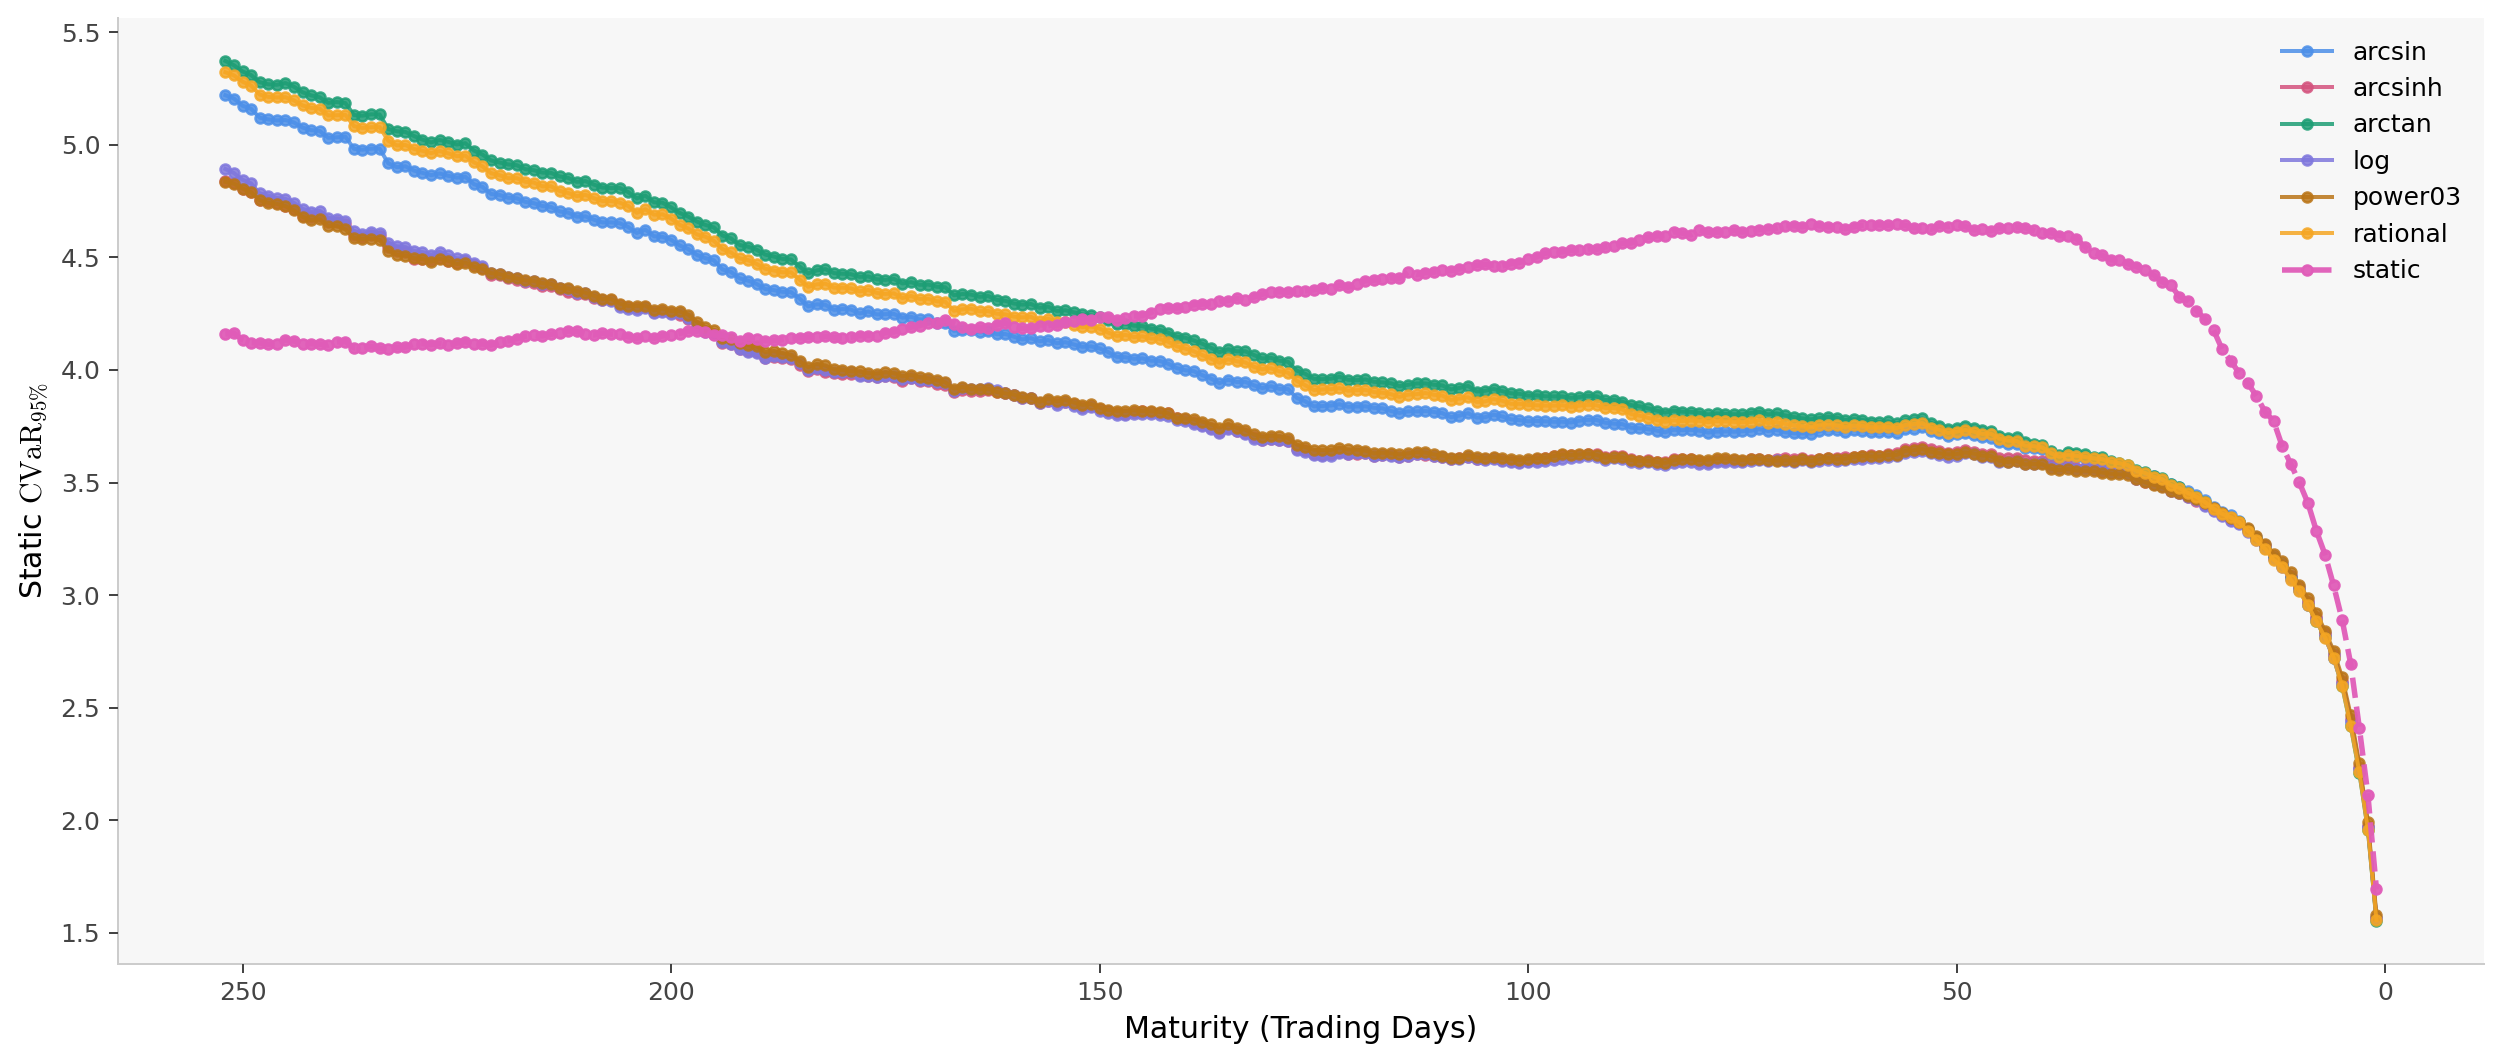


=== alpha975 (alpha=0.975) ===
Saved -> /kaggle/working/figures/pnl_distributions.pdf
Saved -> /kaggle/working/figures/pnl_distributions.png


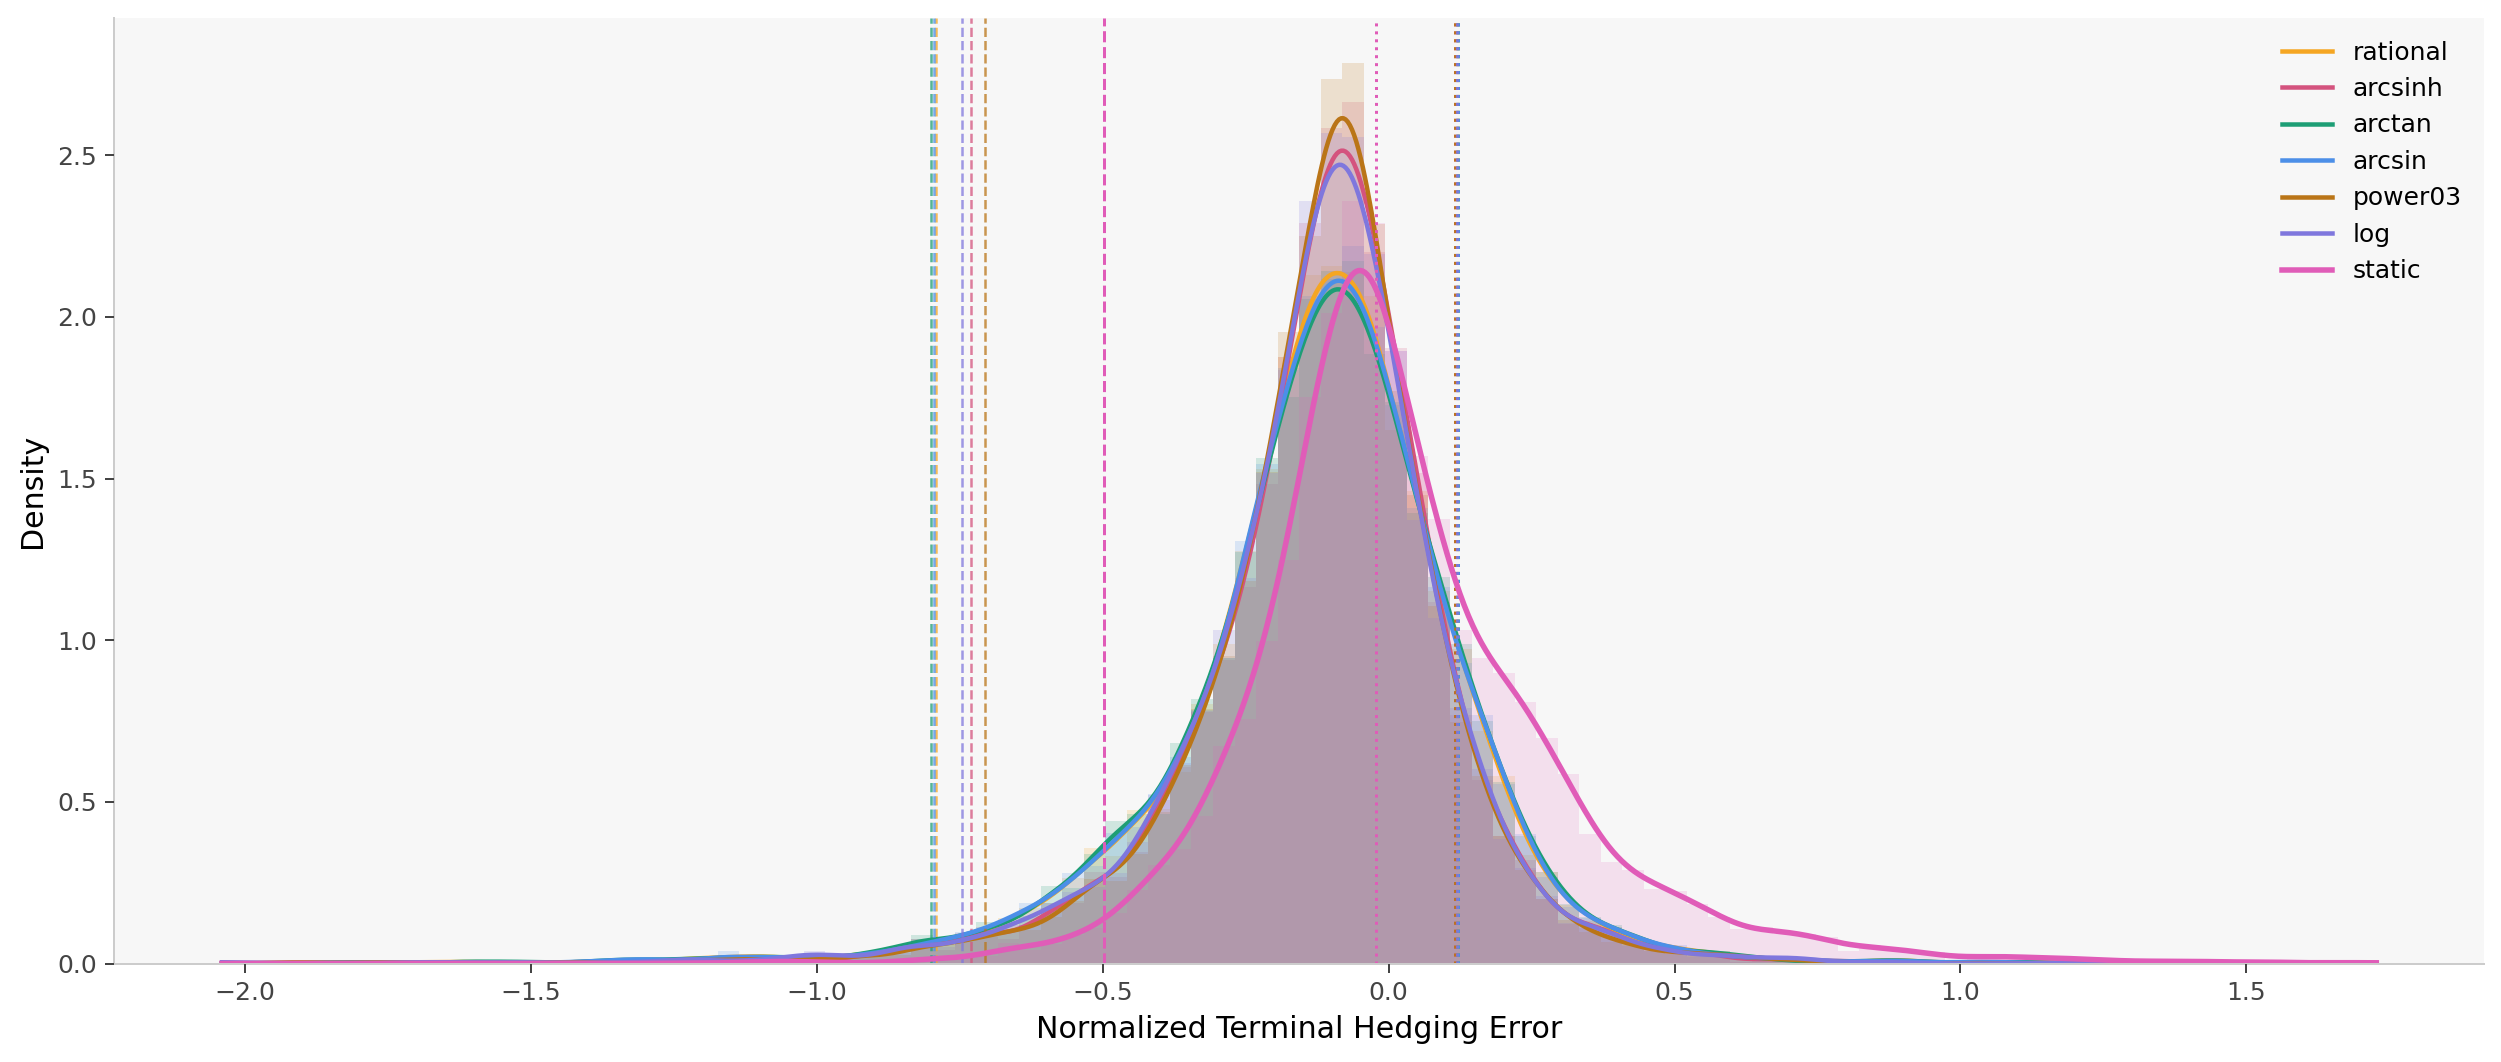

Hard trajectory (max realized gamma P&L, last 20d): idx=294  score=0.924170  (basket start=110.10  end=104.70, moneyness_end=1.047)
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.pdf
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.png


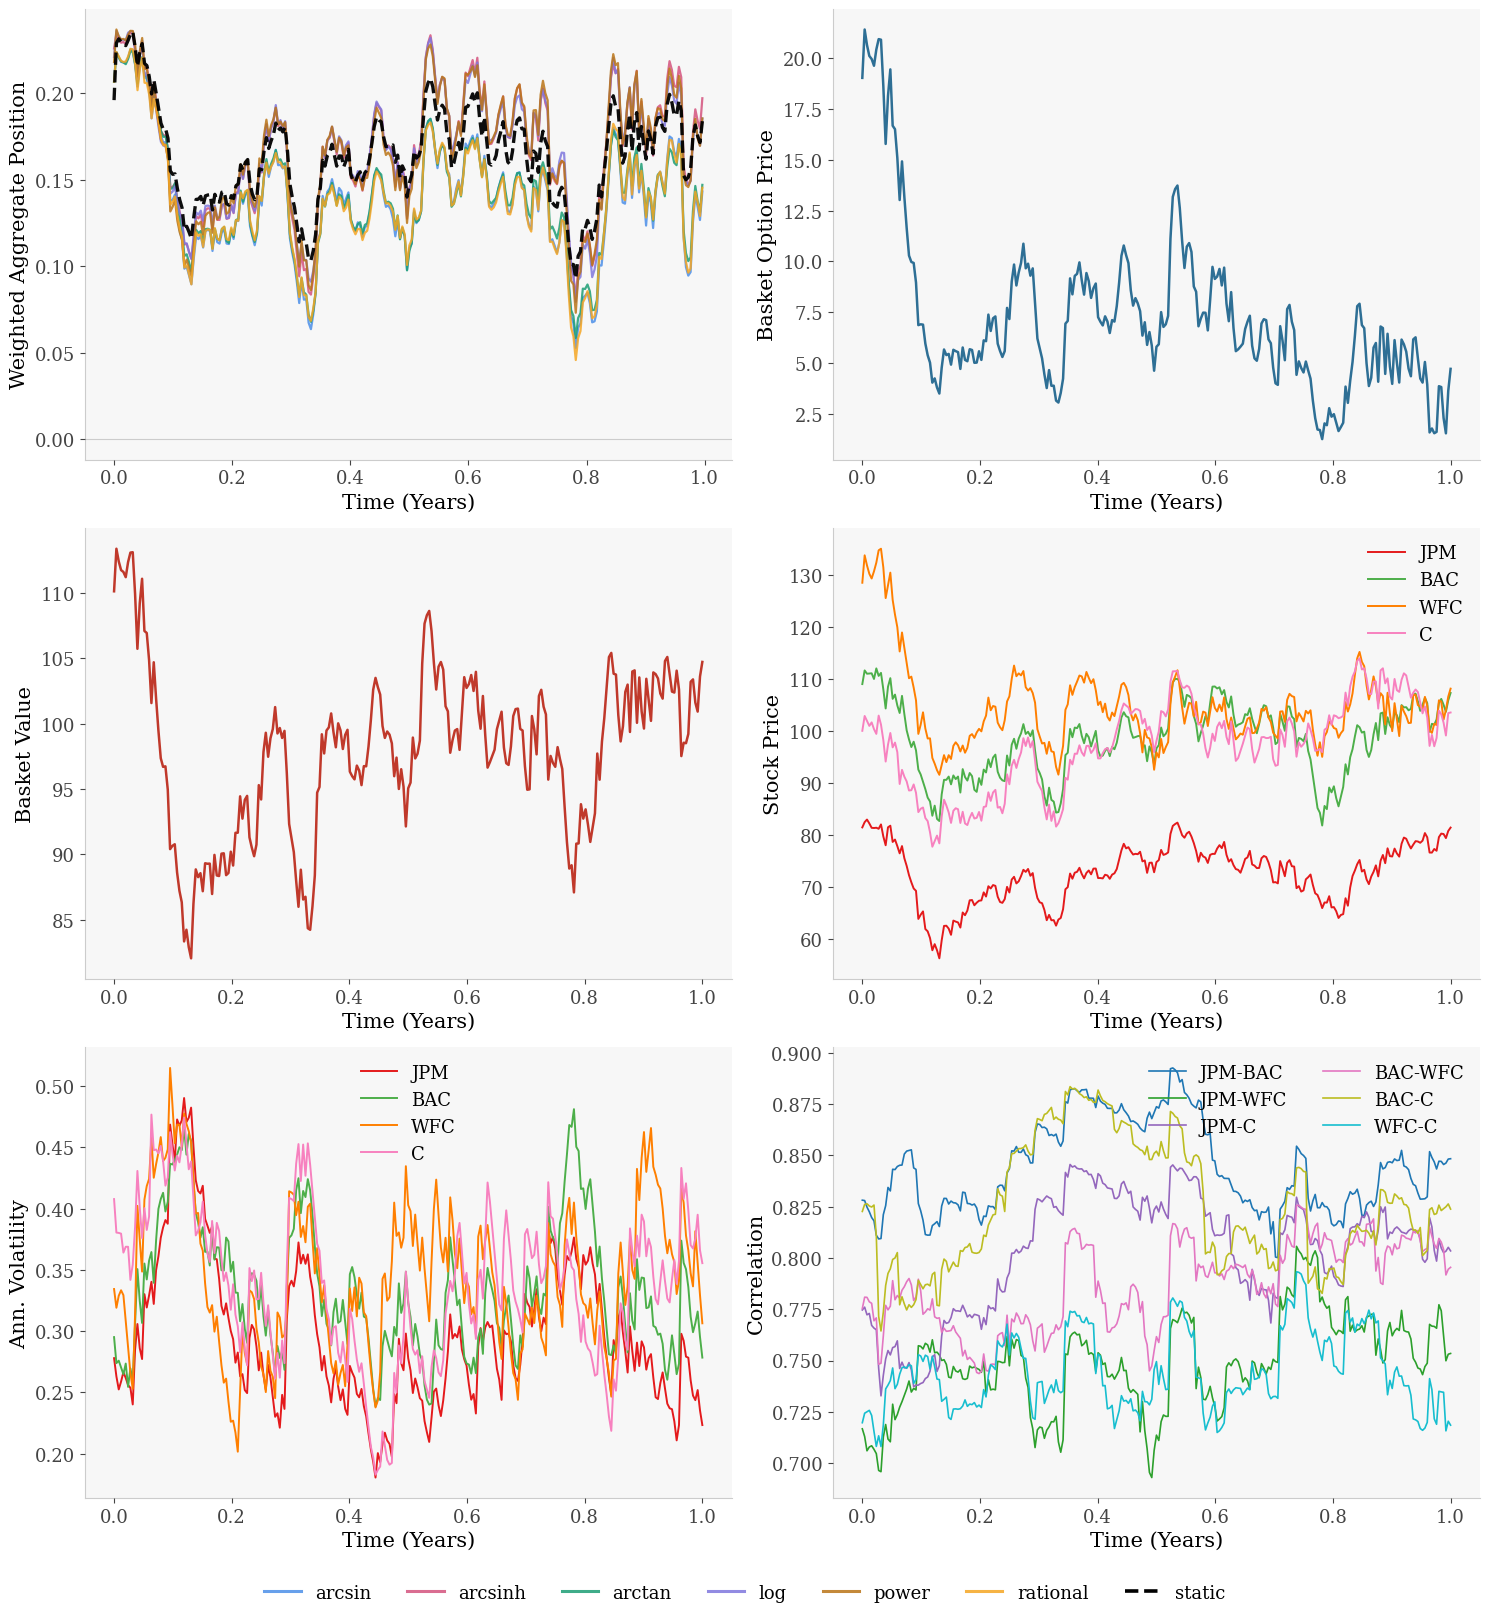


=== alpha99 (alpha=0.99) ===
Saved -> /kaggle/working/figures/pnl_distributions.pdf
Saved -> /kaggle/working/figures/pnl_distributions.png


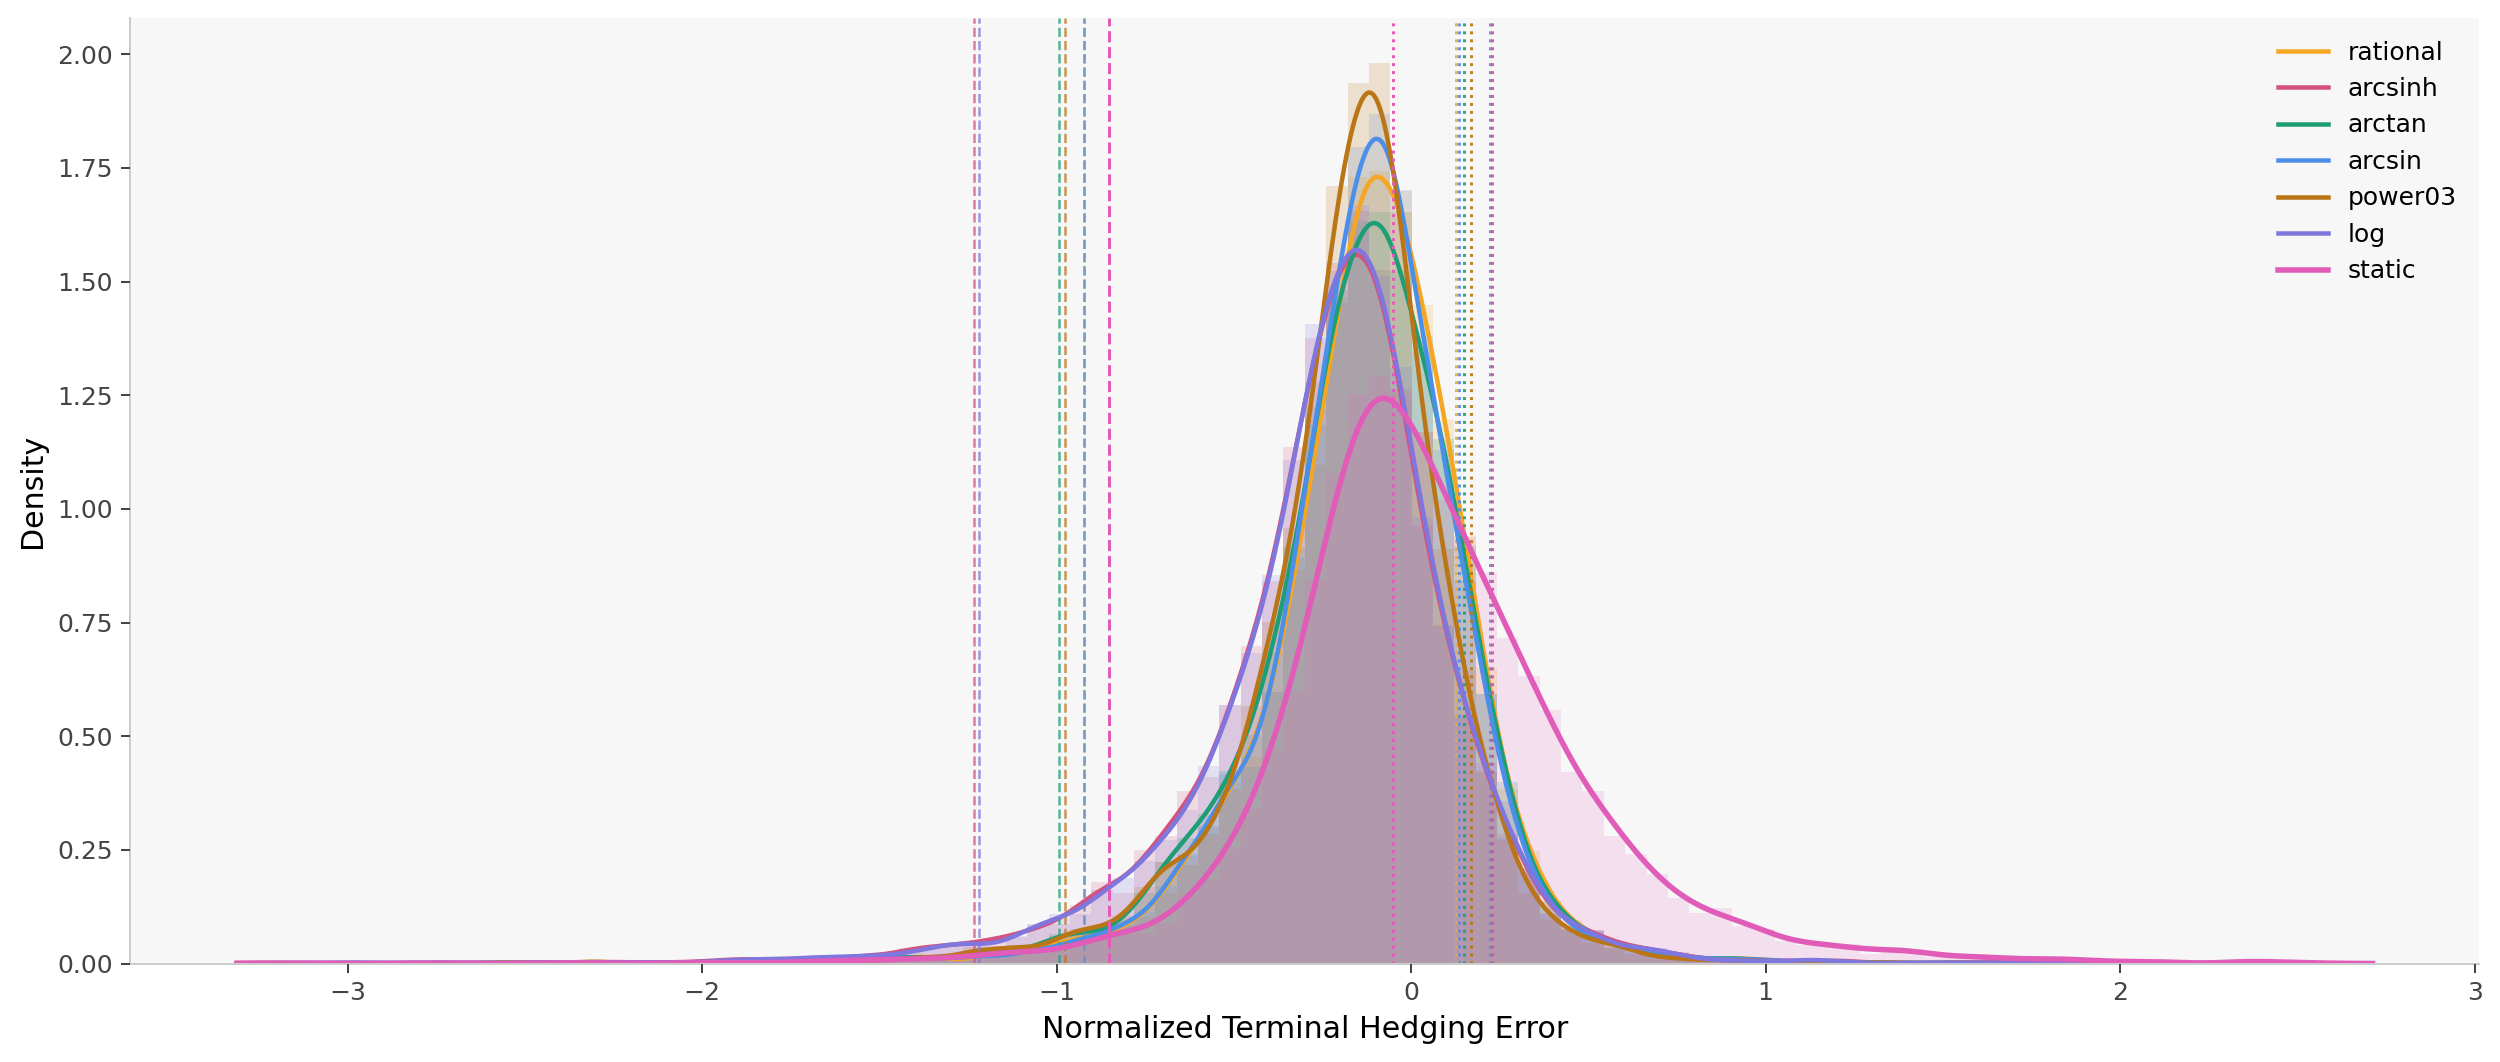

Hard trajectory (max realized gamma P&L, last 20d): idx=294  score=0.924170  (basket start=110.10  end=104.70, moneyness_end=1.047)
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.pdf
Saved -> /kaggle/working/figures/actions_hard_traj_4x2.png


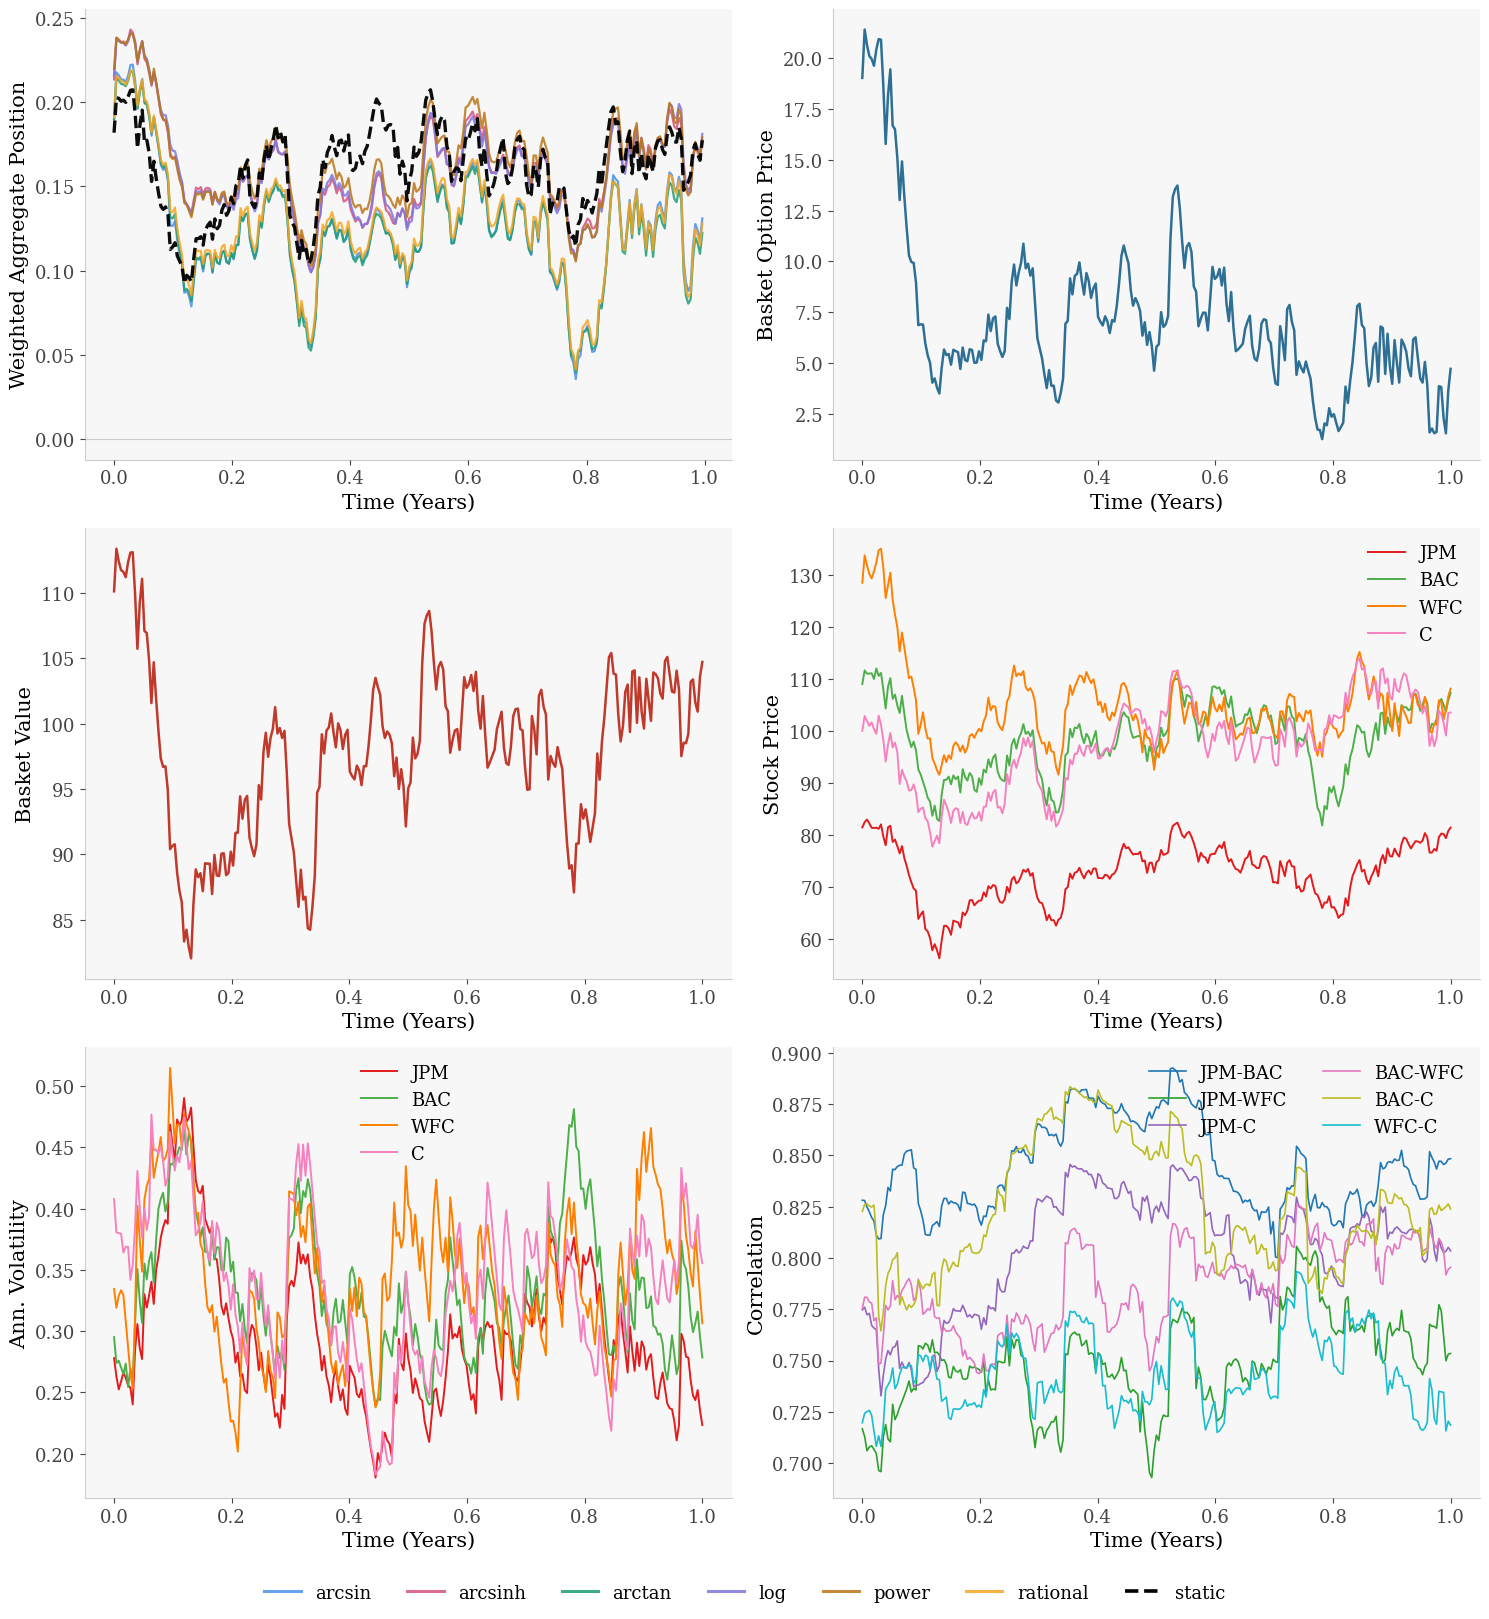

In [ ]:
DATA_DIR     = "/kaggle/working/data"
LOGS_ROOT    = os.path.join(repo_path, "training_run_logs")
PROJECT_ROOT = repo_path
SAVE_DIR     = "/kaggle/working/figures"
os.makedirs(SAVE_DIR, exist_ok=True)


assert "env" in dir(), (
    "`env` is not defined -- run the loader cell before this script."
)


def alpha_variants(alpha_label: str):
    pct = alpha_label.replace("alpha", "")
    val = float(f"0.{pct}")
    return pct, val, f"alpha_{val}"


plot_g2_functions(save_dir=SAVE_DIR)

plot_scoring_curvature(
    score_fn=SCORE_FUNCTIONS["log"],
    save_dir=SAVE_DIR,
)

compute_terminal_stats(
    data_dir=DATA_DIR,
    save_dir=SAVE_DIR,
    alpha_labels=ALPHA_LABELS,
)

FIXED_ALPHA = "alpha95"

for alpha_label in ALPHA_LABELS:
    pct, alpha_val, log_alpha_label = alpha_variants(alpha_label)
    print(f"\n=== {alpha_label} (alpha={alpha_val}) ===")

    if alpha_label == FIXED_ALPHA:
        plot_portfolio_delta(
            alpha_label=alpha_label,
            data_dir=DATA_DIR,
            env=env,
            save_dir=SAVE_DIR,
        )

    plot_pnl_distributions(
        alpha_label=alpha_label,
        data_dir=DATA_DIR,
        save_dir=SAVE_DIR,
    )
    plot_extreme_trajectory(
        alpha_label=alpha_label,
        data_dir=DATA_DIR,
        env=env,
        save_dir=SAVE_DIR,
    )

    if alpha_label == FIXED_ALPHA:
        plot_training_curves_by_scoring(
            logs_root=LOGS_ROOT,
            alpha_label=alpha_label,
            save_dir=SAVE_DIR,
        )
        plot_static_risk_across_maturities(
            env=env,
            Actor=Actor,
            MLPActorStatic=MLPActorStatic,
            HedgingEnv=HedgingEnv,
            project_root=PROJECT_ROOT,
            alpha_label=pct,
            alpha=alpha_val,
            scoring_keys=SCORING_KEYS,
            save_dir=SAVE_DIR,
        )

In [ ]:
%cat /kaggle/working/figures/terminal_stats.csv

alpha,model,mean,std,CVaR_alpha925,CVaR_alpha95,CVaR_alpha975,CVaR_alpha99
alpha925,arcsin,-0.9703984260559082,1.6862541437149048,4.39892578125,4.834730625152588,5.572127342224121,6.4765729904174805
alpha925,arcsinh,-1.1296685934066772,1.7520873546600342,4.571412086486816,4.975058555603027,5.678768634796143,6.6379265785217285
alpha925,arctan,-0.9785973429679871,1.6968519687652588,4.423338413238525,4.856834411621094,5.593513488769531,6.502633094787598
alpha925,log,-1.1196664571762085,1.7496541738510132,4.570196151733398,4.972069263458252,5.657853603363037,6.571918487548828
alpha925,power03,-1.1932622194290161,1.7289927005767822,4.579861164093018,4.981581211090088,5.65872049331665,6.568634510040283
alpha925,rational,-0.9570276141166687,1.6497637033462524,4.310739994049072,4.732717514038086,5.4522199630737305,6.350675582885742
alpha925,static,0.29355716705322266,2.5727920532226562,3.764785051345825,4.091001033782959,4.621938705444336,5.290191173553467
alpha95,arcsin,-1.0912591218948364,1.

In [4]:
DATA_DIR     = "/kaggle/working/data"
LOGS_ROOT    = os.path.join(repo_path, "training_run_logs")
PROJECT_ROOT = repo_path
SAVE_DIR     = "/kaggle/working/figures"
os.makedirs(SAVE_DIR, exist_ok=True)
from src.agents.NestedCritic import CriticVaR

assert "env" in dir(), (
    "`env` is not defined -- run the loader cell before this script."
)



df = compute_fixed_price_comparison(
    all_models, all_norms,
    data_dir=DATA_DIR, save_dir=SAVE_DIR,
    env=env,
    CriticVaR=CriticVaR,
    nested_ckpt_paths={
        ("alpha95", "log"):      "dynamicriskmodels/alpha95/log/NestedCriticlogalpha95.pt",
        ("alpha95", "rational"): "dynamicriskmodels/alpha95/rational/NestedCriticrationalalpha95.pt",
    },
)
display(df)

average price: 12.035446166992188, path 0 price: 12.035446166992188
average price: 12.035446166992188, path 0 price: 12.035446166992188
average price: 12.035446166992188, path 0 price: 12.035446166992188
average price: 12.035446166992188, path 0 price: 12.035446166992188
Saved -> /kaggle/working/figures/fixed_price_comparison.csv

DRM price by (alpha x scoring_fn), SRM price for reference (fixed S0=[100,100,100,100], h0=unconditional variance):
scoring_fn      arcsin     arcsinh      arctan         log     power03  \
alpha                                                                    
alpha925     77.673203  114.945160   79.206406  114.889145  102.159882   
alpha95     107.756897  137.576279  110.579178  137.217827  125.178421   
alpha975    172.265869  202.462708  176.852890  202.964310  181.276291   
alpha99     216.332870  397.769547  223.040436  396.416977  346.866623   

scoring_fn    rational        SRM  
alpha                              
alpha925     76.848442  15.741583 

,alpha,scoring_fn,DRM_price,SRM_price,Nested_price
0,alpha925,arcsin,77.673203,15.741583,NaN
1,alpha925,arcsinh,114.945160,15.741583,NaN
2,alpha925,arctan,79.206406,15.741583,NaN
3,alpha925,log,114.889145,15.741583,NaN
4,alpha925,power03,102.159882,15.741583,NaN
5,alpha925,rational,76.848442,15.741583,NaN
6,alpha95,arcsin,107.756897,16.139974,NaN
7,alpha95,arcsinh,137.576279,16.139974,NaN
8,alpha95,arctan,110.579178,16.139974,NaN
9,alpha95,log,137.217827,16.139974,137.905518
